# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 26     |  |
| :-------------|:-------------|
| Bob Villerius | 6483895 |
| Adam Echant Hamdioui| 6563031 |
| Dexter Mourik| 6270433 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Bob Villerius', 'Adam Echant Hamdioui']

## Opdracht 1: Planning.

| Planning Groep: 26     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie af | 11:20 |
| Meetopstelling getest | 12:00 |
| Pauze 1 | 12:30-13:45 |
| Algoritmes bedacht | 13:45 |
| Eerste poging | 14:30 |
| Iteratie 1 | 15:15 |
| Algoritme af en controleren door TA| 16:00 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [26]
<img src="kalibratie.jpg" width="400">

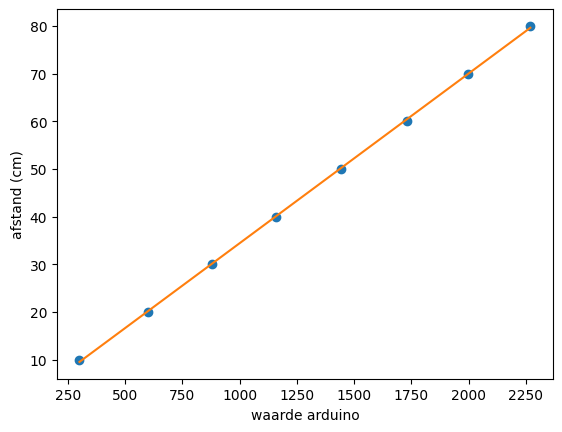

De kalibratieformule is: Afstand = 0.036 * waarde_arduino + -1.173


In [3]:
# verwerk hier jullie kalibratiemetingen 
from scipy.optimize import curve_fit

afstand_kalibratie=np.array([10,20, 30, 40, 50, 60, 70, 80]) #cm
waarde_arduino_kalibratie=np.array([301, 600, 880, 1160, 1441, 1730, 1997, 2270])
# Lineair verband

def kalibratie(x, a, b):
    return a*x + b

val, cov=curve_fit(kalibratie, waarde_arduino_kalibratie, afstand_kalibratie)

plt.figure()
plt.plot(waarde_arduino_kalibratie, afstand_kalibratie, 'o')
plt.plot(waarde_arduino_kalibratie, kalibratie(waarde_arduino_kalibratie, *val), label='fit: a=%5.3f, b=%5.3f' % tuple(val))
plt.xlabel('waarde arduino')
plt.ylabel('afstand (cm)')
plt.show()
print(f"De kalibratieformule is: Afstand = {val[0]:.3f} * waarde_arduino + {val[1]:.3f}")

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  40.50
1   0  30   0  20  40.80
2  40   0  30   0  40.05
3  30   0  20   0  41.00


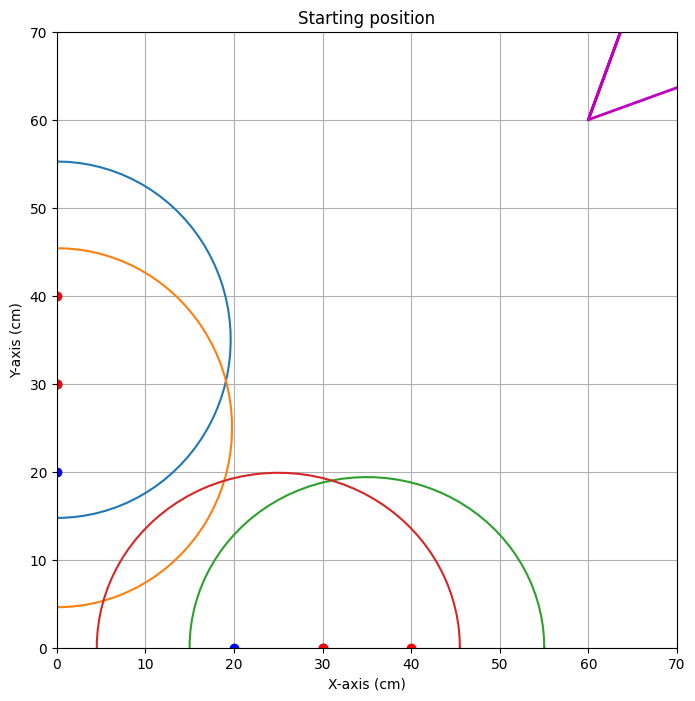


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.367


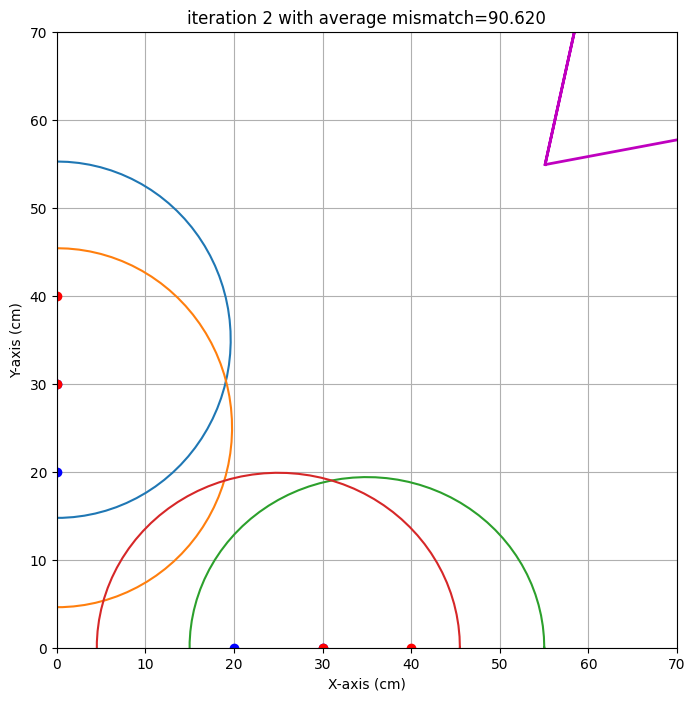

end iteration 2 with average mismatch=90.620


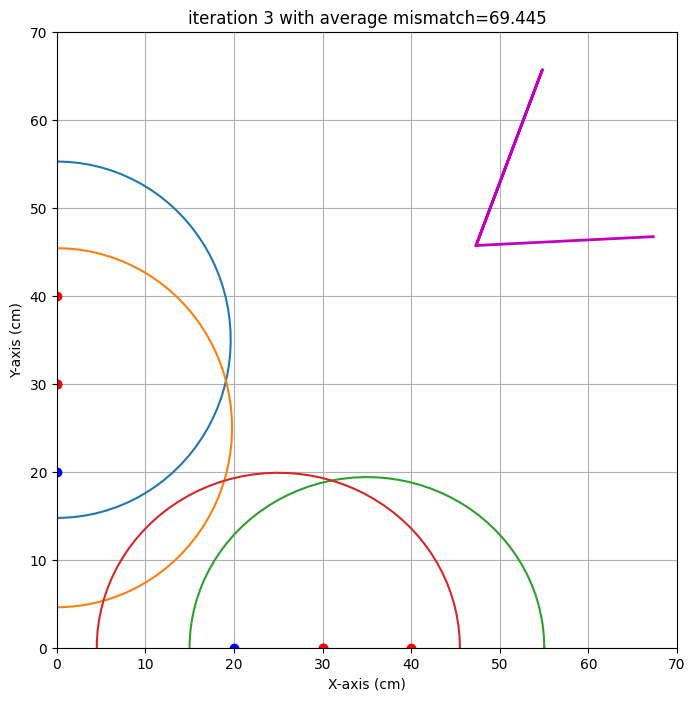

end iteration 3 with average mismatch=69.445


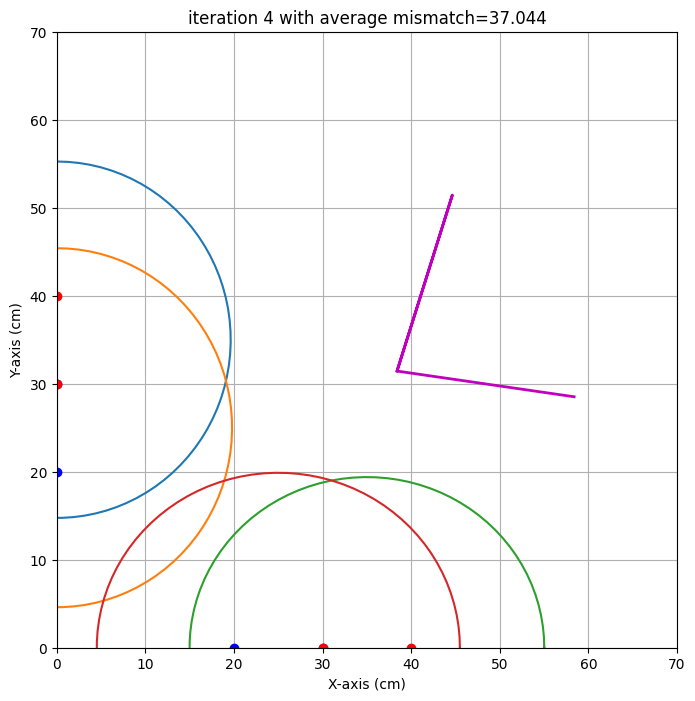

end iteration 4 with average mismatch=37.044


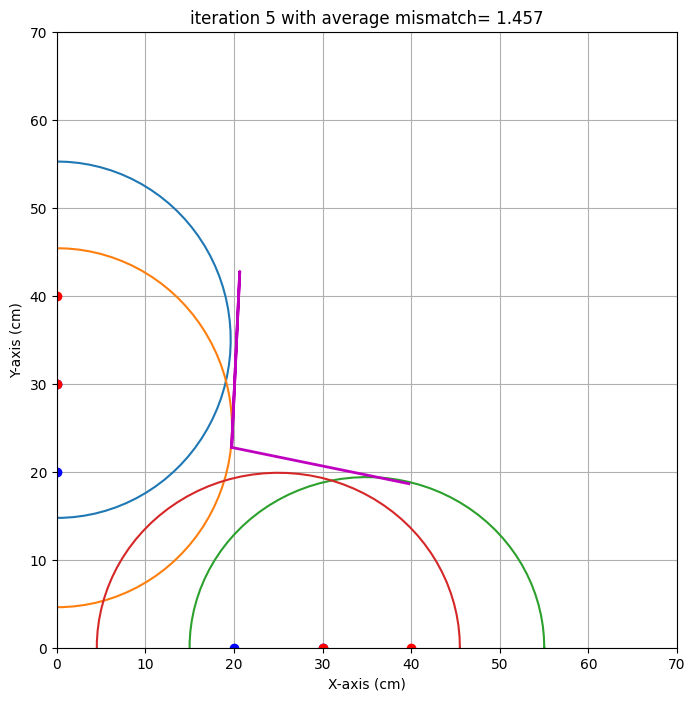

end iteration 5 with average mismatch= 1.457


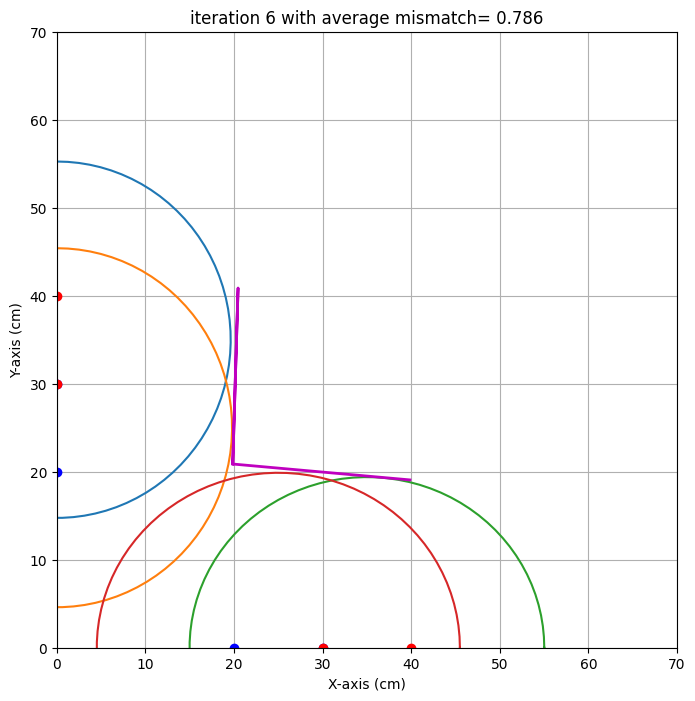

end iteration 6 with average mismatch= 0.786
end iteration 7 with average mismatch= 0.734


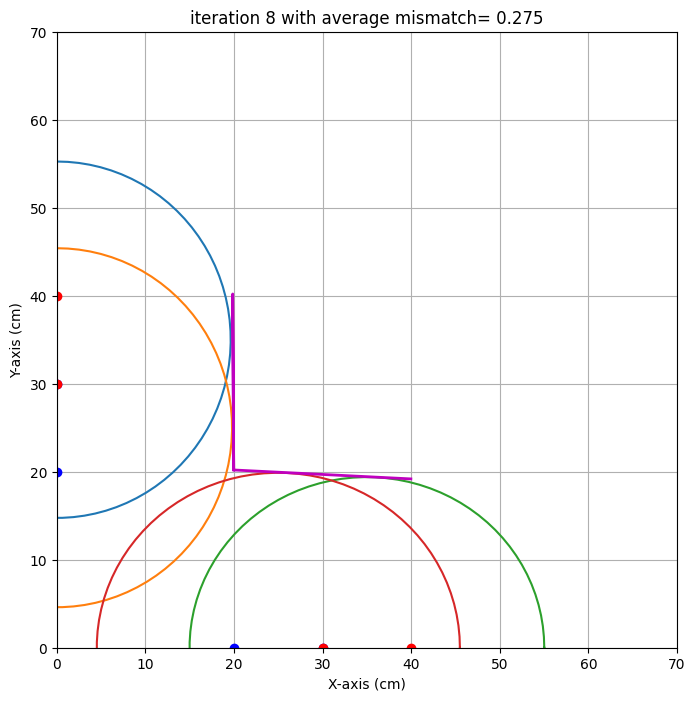

end iteration 8 with average mismatch= 0.275


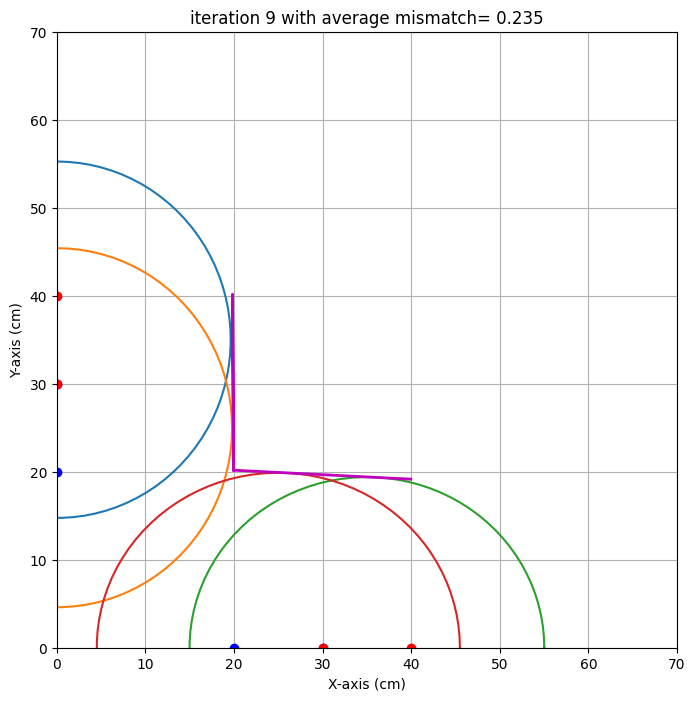

end iteration 9 with average mismatch= 0.235
end iteration 10 with average mismatch= 0.234
end iteration 11 with average mismatch= 0.234
end iteration 12 with average mismatch= 0.234
end iteration 13 with average mismatch= 0.234
end iteration 14 with average mismatch= 0.234
end iteration 15 with average mismatch= 0.234
end iteration 16 with average mismatch= 0.234
end iteration 17 with average mismatch= 0.234
end iteration 18 with average mismatch= 0.234
end iteration 19 with average mismatch= 0.234
end iteration 20 with average mismatch= 0.234
end iteration 21 with average mismatch= 0.234
end iteration 22 with average mismatch= 0.234
end iteration 23 with average mismatch= 0.234
end iteration 24 with average mismatch= 0.234
end iteration 25 with average mismatch= 0.234
end iteration 26 with average mismatch= 0.234
end iteration 27 with average mismatch= 0.234
end iteration 28 with average mismatch= 0.234
end iteration 29 with average mismatch= 0.234
Last iteration, also determine unce

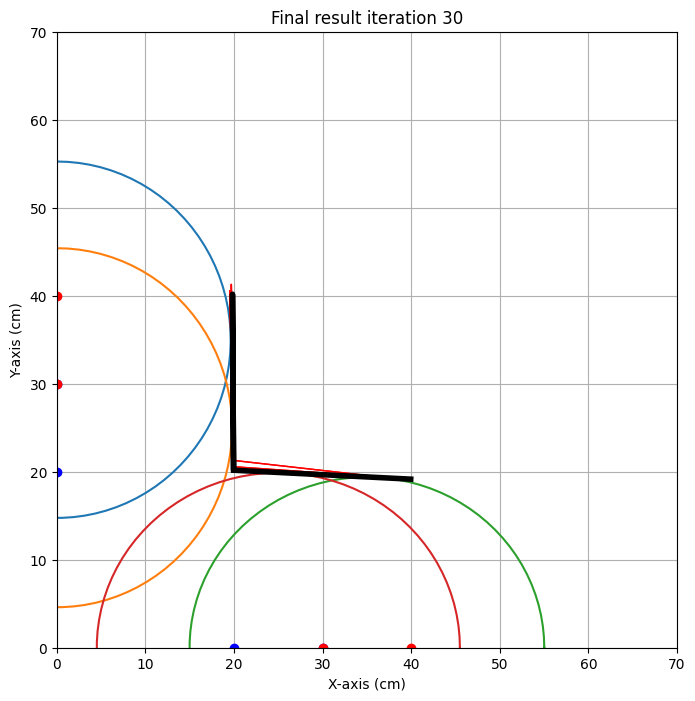

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.8],
    #[0,10,0,20,49.5],
    [40,0,30,0,40.05],
    [30,0,20,0,41.0],
    #[10,0,20,0,47],
    #[10,0,0,10,]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.9 cm met een standaardafwijking van 0.1 cm 
y0: 20.2 cm met een standaardafwijking van 1.1 cm 
alpha: -2.9 graden met een standaardafwijking van 3.6 graad 
beta: -0.3 graden met een standaardafwijking van 0.6 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Bob Villerius]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algorBob.jpeg" width="400">

#### algoritme [Adam Echant Hamdioui]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algorAdam1.jpeg" width="400">
<img src="algorAdam2.jpeg" width="400">

#### algoritme [Dexter Mourik]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algorDexter.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':29,  #zelf aanvullen,
           'y0':39,#zelf aanvullen,
           'alpha' :-11, #zelf aanvullen,
           'beta' : -19#zelf aanvullen},    
}       

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Bob Villerius' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[20,0,40,0,x],
   [0,50,0,70,70.2], 
   [0,45,0,65,67.12],
   [20,0,40,0, 76.95],
   [25,0,45,0, 75]
    ])
,
       'Adam Echant Hamdioui' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,0,50,x],
   [70,0,50,0,70],
   [0,50,0,30,72.6],
   #[50,0,30,0,x],
   [0,40,0,20, 77.34]
   #[0,40,0,20,x]
    ])}

## Opdracht 7: Evaluatie.

Bob Villerius
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  70  70.20
1   0  45   0  65  67.12
2  20   0  40   0  76.95
3  25   0  45   0  75.00


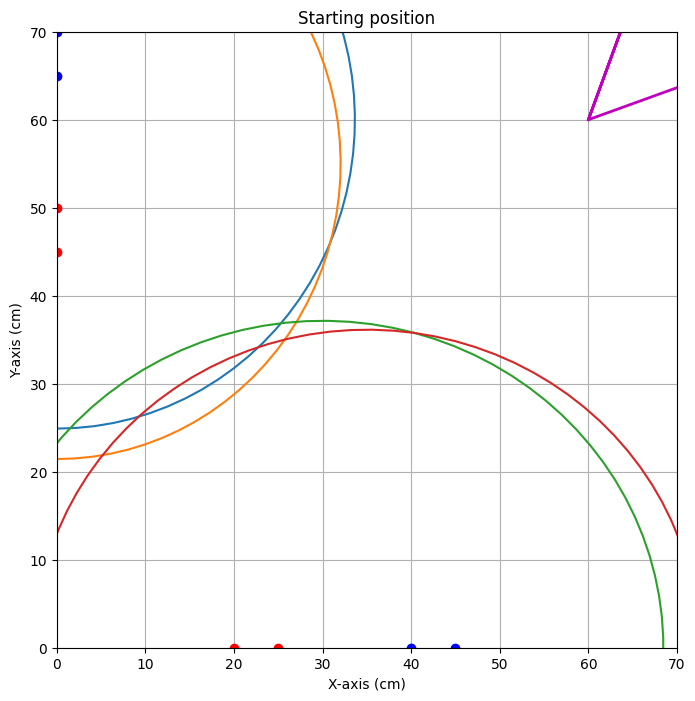


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.666


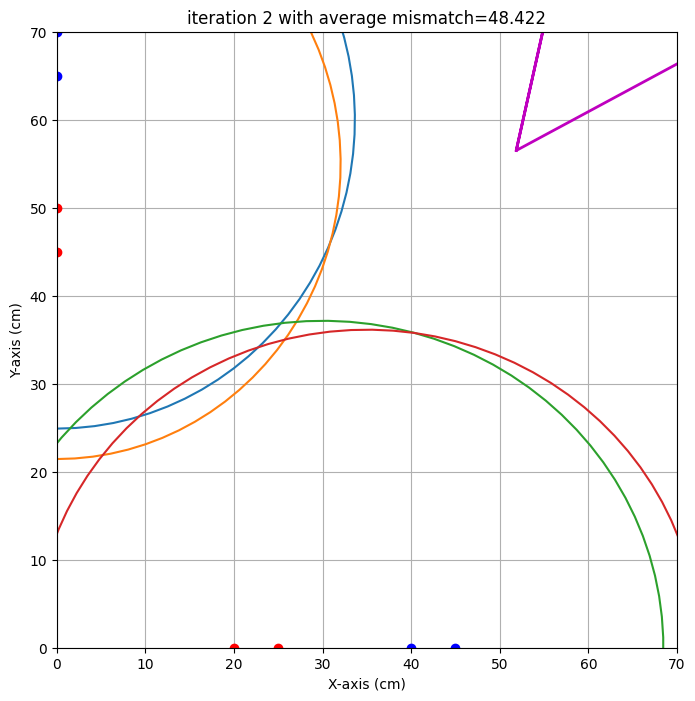

end iteration 2 with average mismatch=48.422


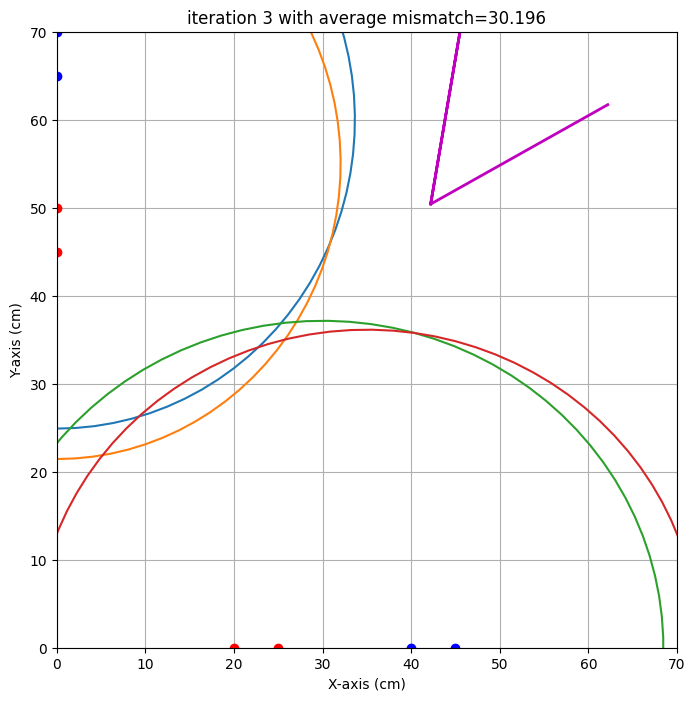

end iteration 3 with average mismatch=30.196


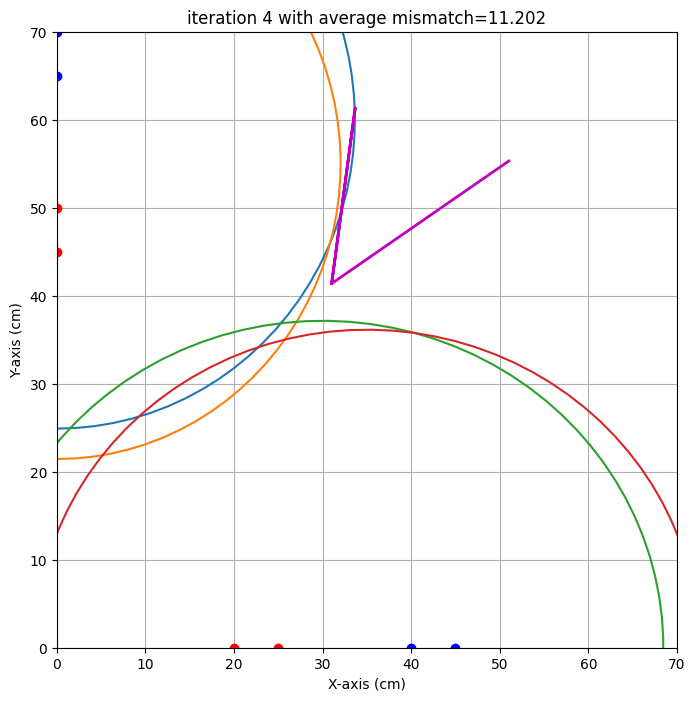

end iteration 4 with average mismatch=11.202


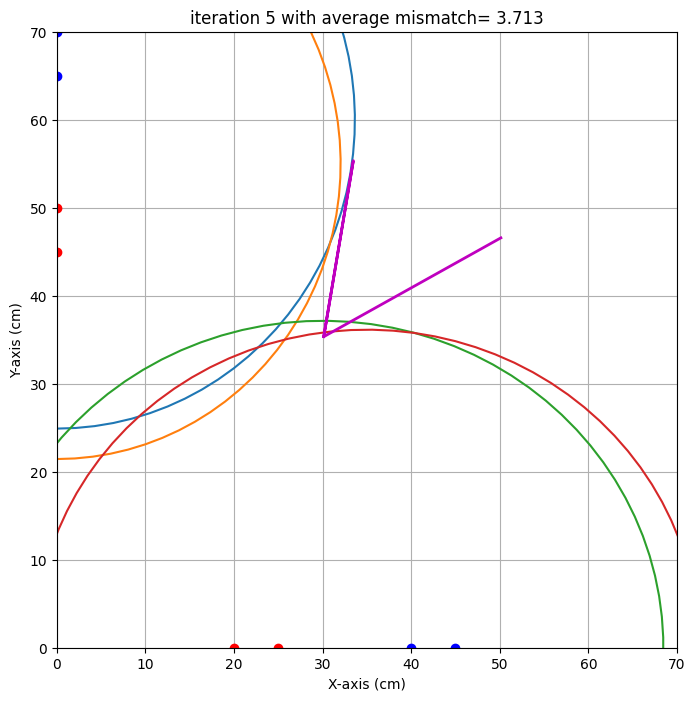

end iteration 5 with average mismatch= 3.713


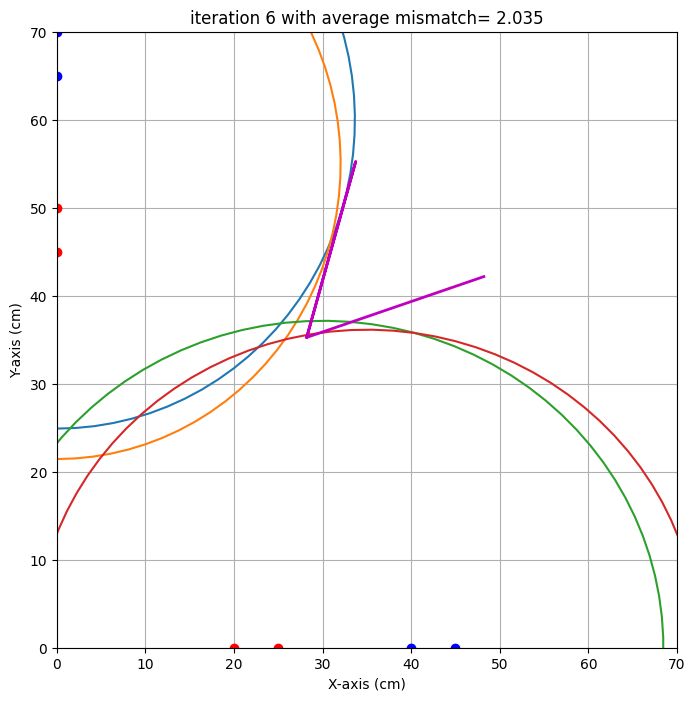

end iteration 6 with average mismatch= 2.035


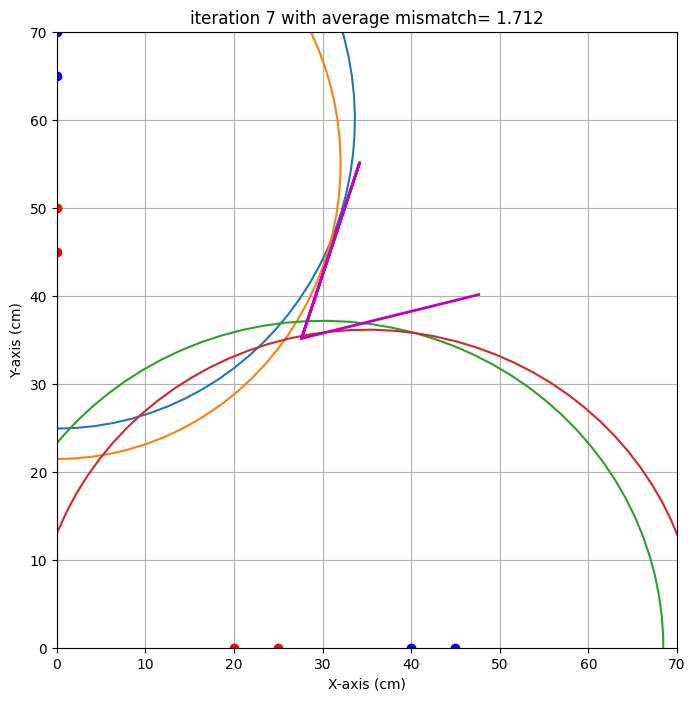

end iteration 7 with average mismatch= 1.712


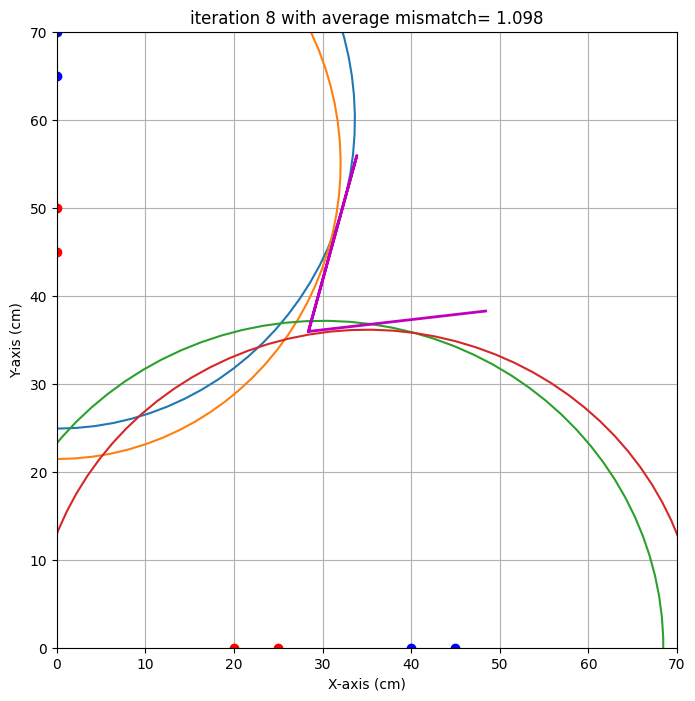

end iteration 8 with average mismatch= 1.098
end iteration 9 with average mismatch= 1.095
end iteration 10 with average mismatch= 1.036


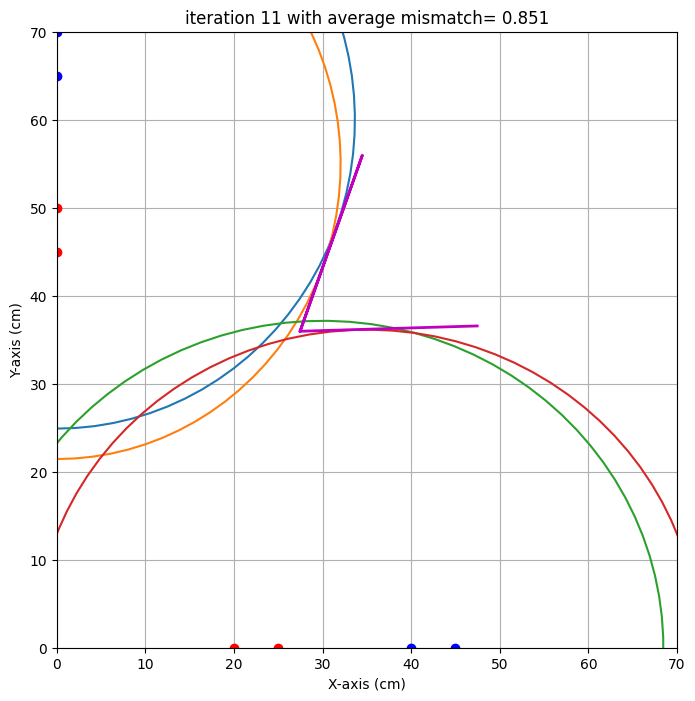

end iteration 11 with average mismatch= 0.851
end iteration 12 with average mismatch= 0.833


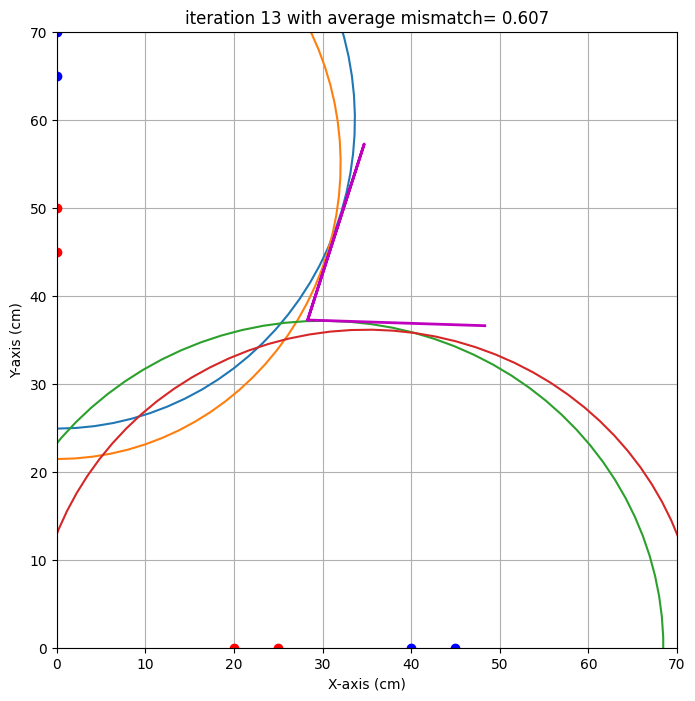

end iteration 13 with average mismatch= 0.607
end iteration 14 with average mismatch= 0.584


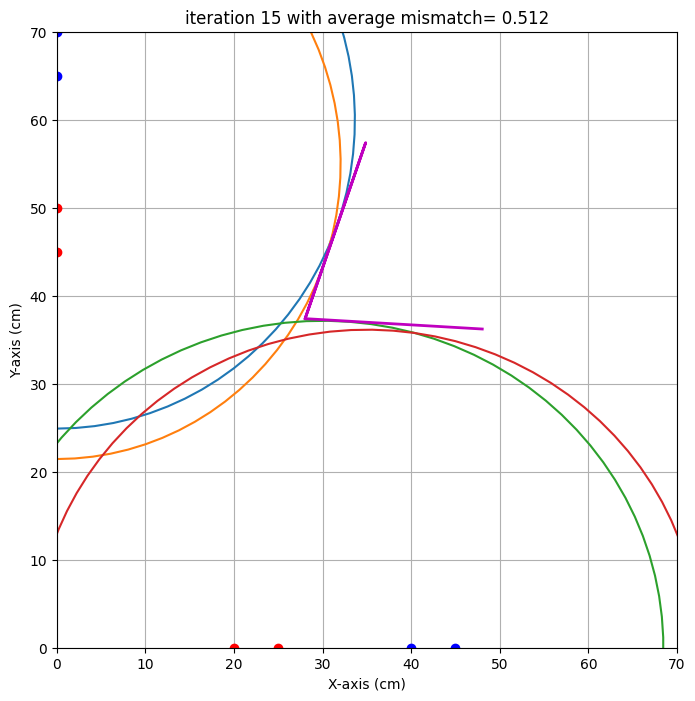

end iteration 15 with average mismatch= 0.512


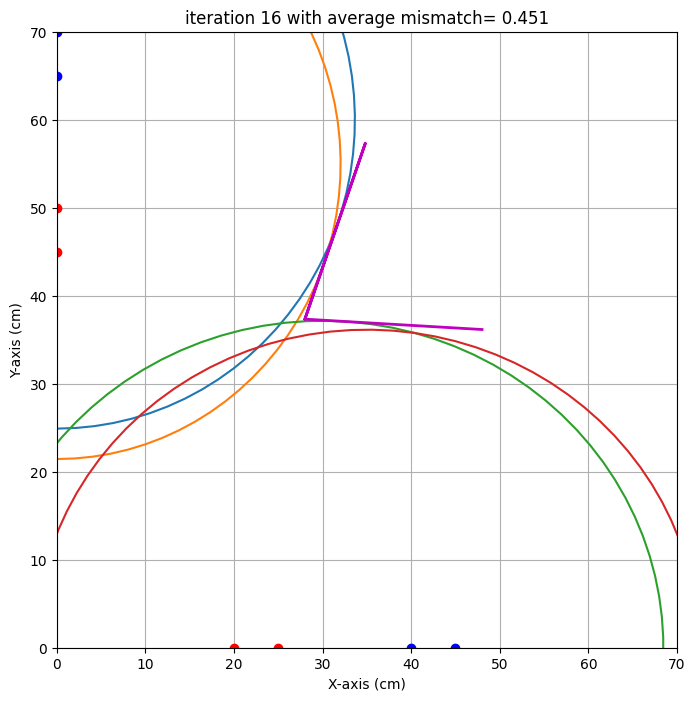

end iteration 16 with average mismatch= 0.451
end iteration 17 with average mismatch= 0.451
end iteration 18 with average mismatch= 0.451
end iteration 19 with average mismatch= 0.451
end iteration 20 with average mismatch= 0.451


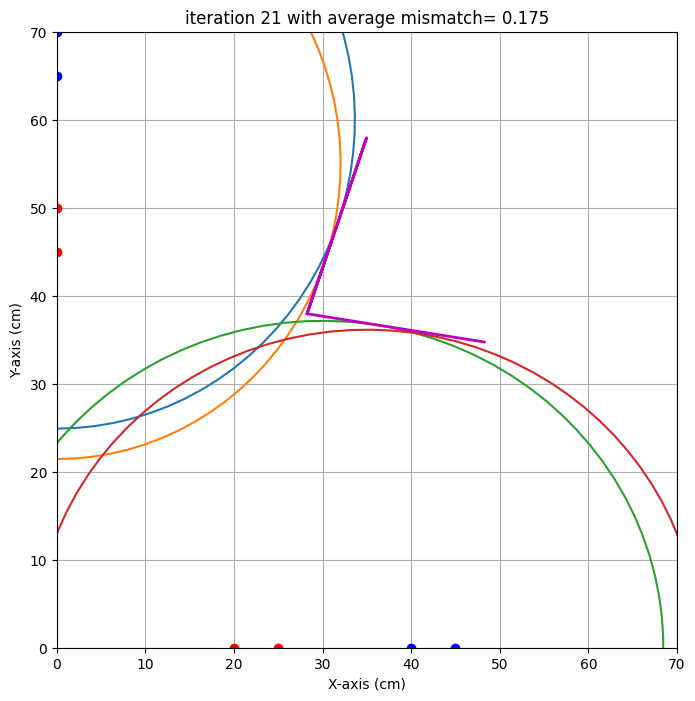

end iteration 21 with average mismatch= 0.175
end iteration 22 with average mismatch= 0.167
end iteration 23 with average mismatch= 0.167
end iteration 24 with average mismatch= 0.167
end iteration 25 with average mismatch= 0.167
end iteration 26 with average mismatch= 0.167
end iteration 27 with average mismatch= 0.167
end iteration 28 with average mismatch= 0.167
end iteration 29 with average mismatch= 0.167
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.167
###############################################################################
end of iteration  30
Best alpha=  -9.12 with uncertainty=   3.81
Best beta =  18.57 with uncertainty=   3.72
Best x0   =  28.24 with uncertainty=   0.44
Best y0   =  37.94 with uncertainty=   0.37
###############################################################################


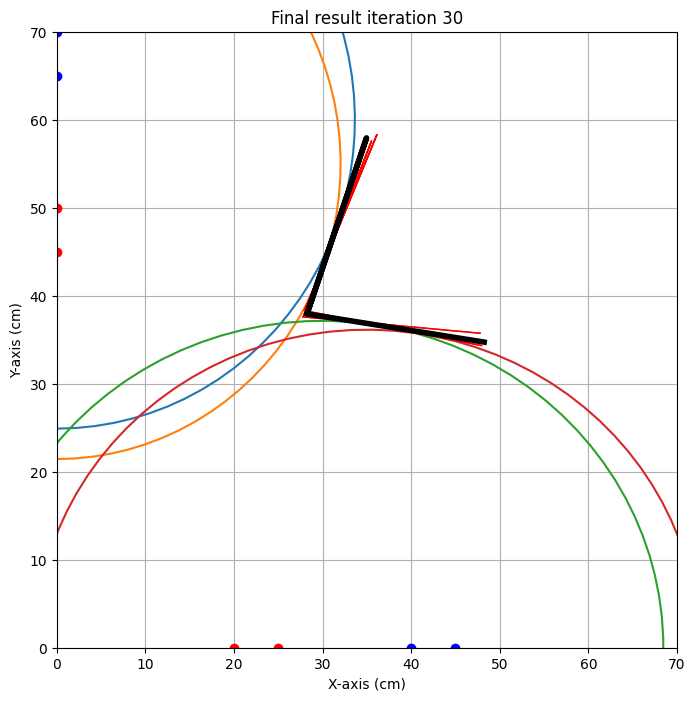

{'alpha': np.float64(-9.115381749950995), 'alpha_eps': np.float64(3.8138717770431283), 'beta': np.float64(18.565828314043287), 'beta_eps': np.float64(3.7176007689708506), 'x0': np.float64(28.23976596753033), 'x0_eps': np.float64(0.4385317551741572), 'y0': np.float64(37.93881265889975), 'y0_eps': np.float64(0.37338085649645336)}
Adam Echant Hamdioui
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  50   0  70.00
1   0  50   0  30  72.60
2   0  40   0  20  77.34


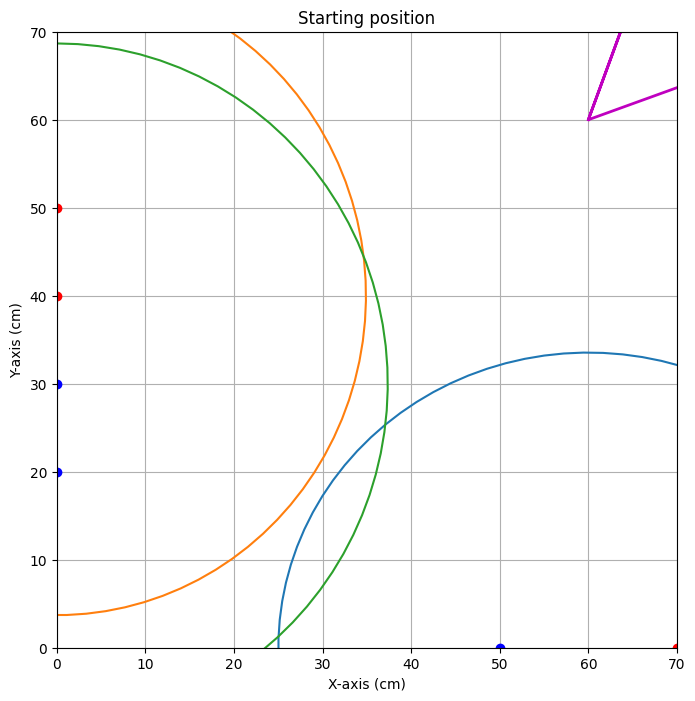


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.238


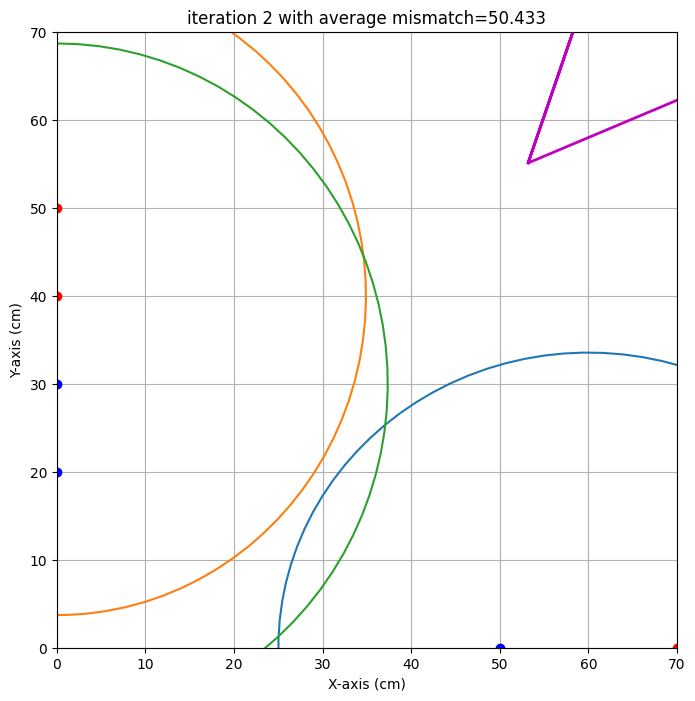

end iteration 2 with average mismatch=50.433


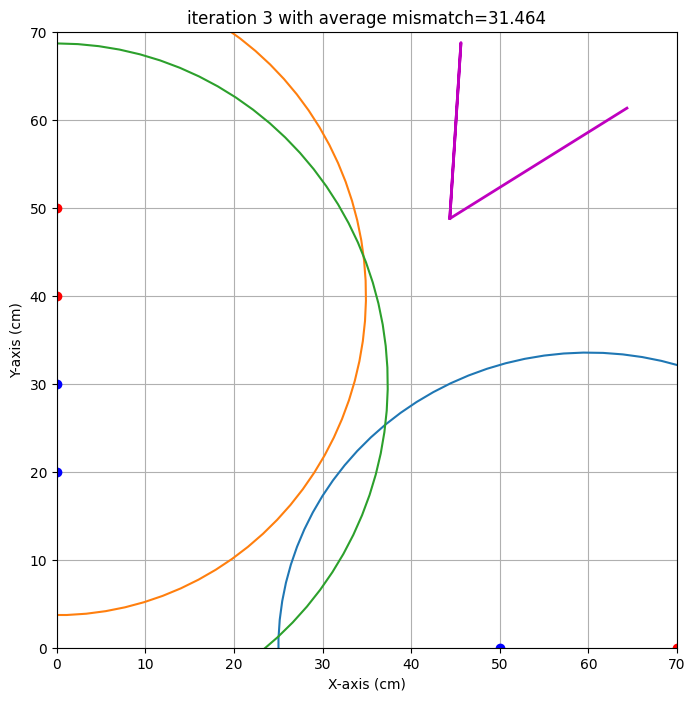

end iteration 3 with average mismatch=31.464


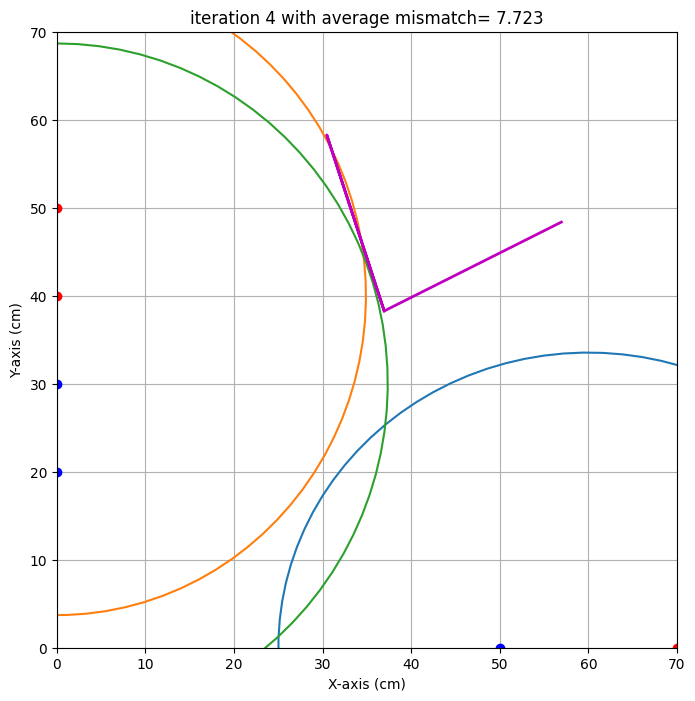

end iteration 4 with average mismatch= 7.723


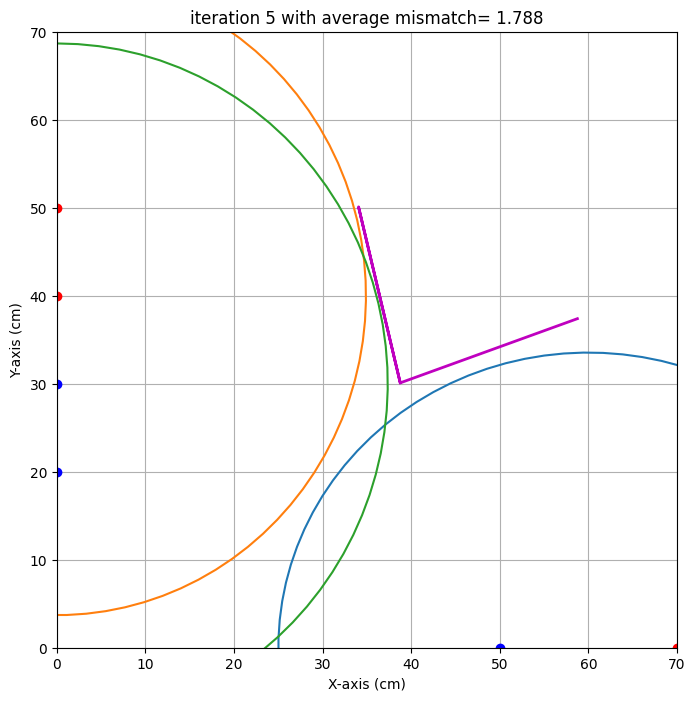

end iteration 5 with average mismatch= 1.788


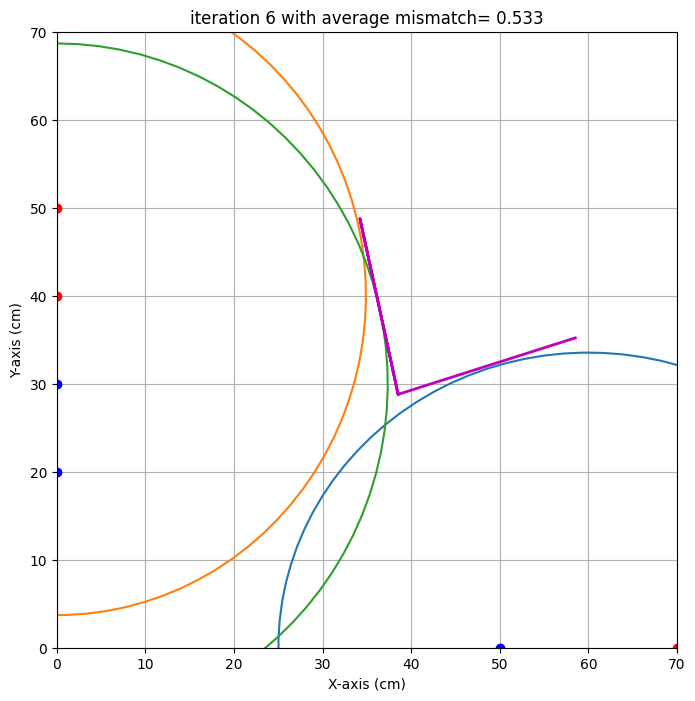

end iteration 6 with average mismatch= 0.533


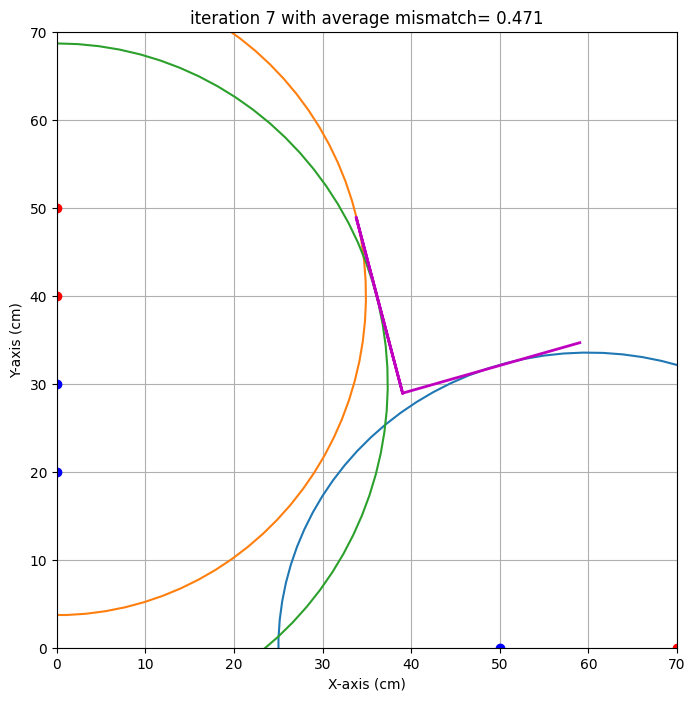

end iteration 7 with average mismatch= 0.471
end iteration 8 with average mismatch= 0.469
end iteration 9 with average mismatch= 0.464
end iteration 10 with average mismatch= 0.464
end iteration 11 with average mismatch= 0.455


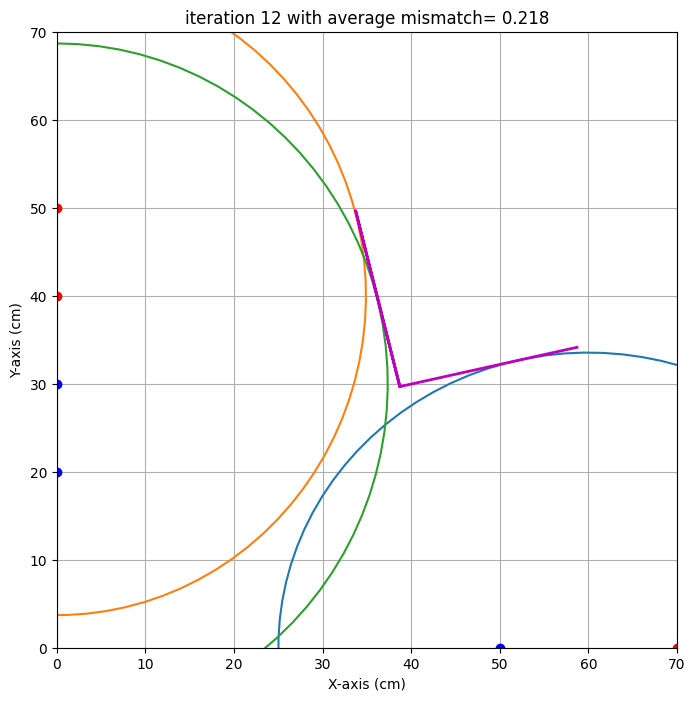

end iteration 12 with average mismatch= 0.218


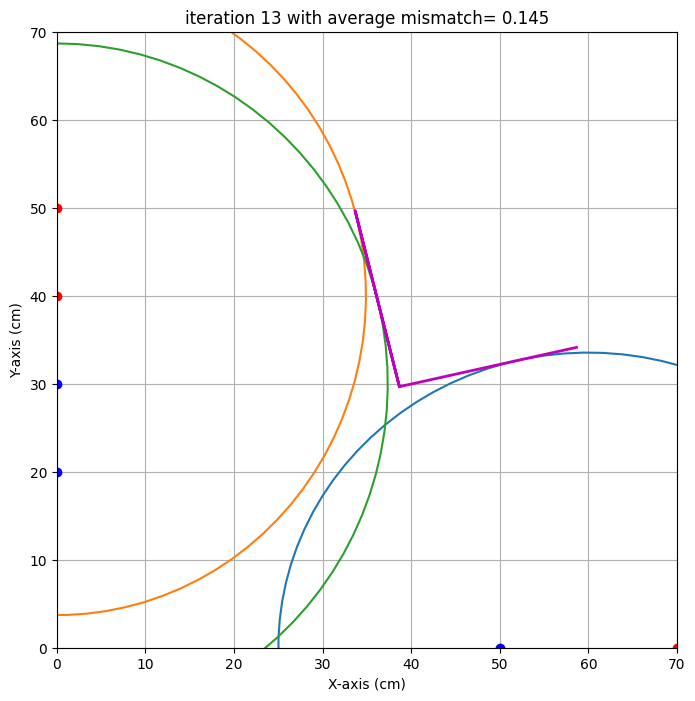

end iteration 13 with average mismatch= 0.145
end iteration 14 with average mismatch= 0.145
end iteration 15 with average mismatch= 0.145
end iteration 16 with average mismatch= 0.145
end iteration 17 with average mismatch= 0.145
end iteration 18 with average mismatch= 0.145
end iteration 19 with average mismatch= 0.145
end iteration 20 with average mismatch= 0.145
end iteration 21 with average mismatch= 0.145
end iteration 22 with average mismatch= 0.145
end iteration 23 with average mismatch= 0.145
end iteration 24 with average mismatch= 0.145
end iteration 25 with average mismatch= 0.145
end iteration 26 with average mismatch= 0.145
end iteration 27 with average mismatch= 0.145
end iteration 28 with average mismatch= 0.145
end iteration 29 with average mismatch= 0.145
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.145
###############################################################

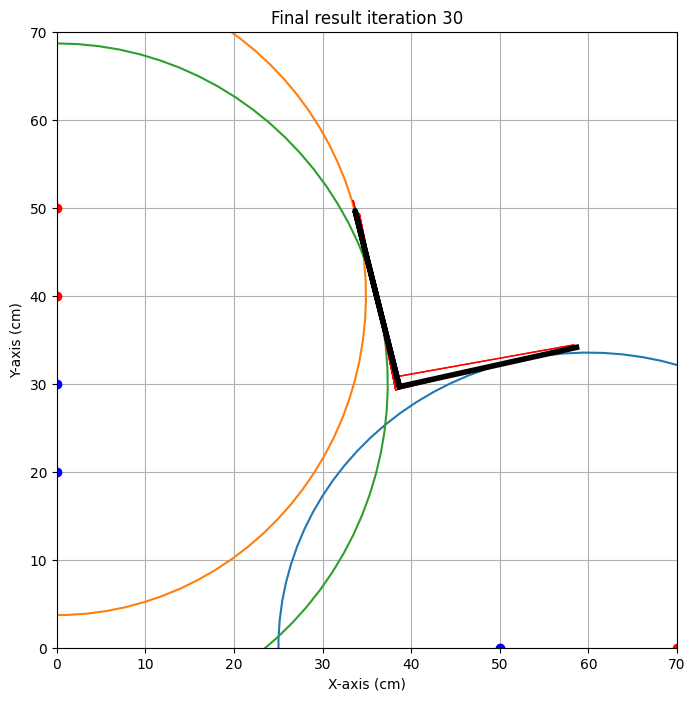

{'alpha': np.float64(12.581677234237281), 'alpha_eps': np.float64(2.357142080039024), 'beta': np.float64(-14.038988082919994), 'beta_eps': np.float64(2.4355204945519713), 'x0': np.float64(38.663032204343196), 'x0_eps': np.float64(0.40948817554285455), 'y0': np.float64(29.665060741698714), 'y0_eps': np.float64(1.1369996593354088)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Bob Villerius 
x0 target is : 29.0. Gevonden waarde: 28.2 cm met een standaardafwijking van 0.4 cm 
y0 target is : 39.0. Gevonden waarde: 37.9 cm met een standaardafwijking van 0.4 cm 
alpha target is : -11.0. Gevonden waarde: -9.1 graden met een standaardafwijking van 3.8 graad 
beta target is : -19.0. Gevonden waarde: 18.6 graden met een standaardafwijking van 3.7 graad 

Adam Echant Hamdioui 
x0 target is : 29.0. Gevonden waarde: 38.7 cm met een standaardafwijking van 0.4 cm 
y0 target is : 39.0. Gevonden waarde: 29.7 cm met een standaardafwijking van 1.1 cm 
alpha target is : -11.0. Gevonden waarde: 12.6 graden met een standaardafwijking van 2.4 graad 
beta target is : -19.0. Gevonden waarde: -14.0 graden met een standaardafwijking van 2.4 graad 



## Opdracht 8: Iteratie1+. 14:48.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Algorfinal.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  20   0  40   0  107
1  15   0  35   0  115
2   0  50   0  70   90
3   0  45   0  65   89


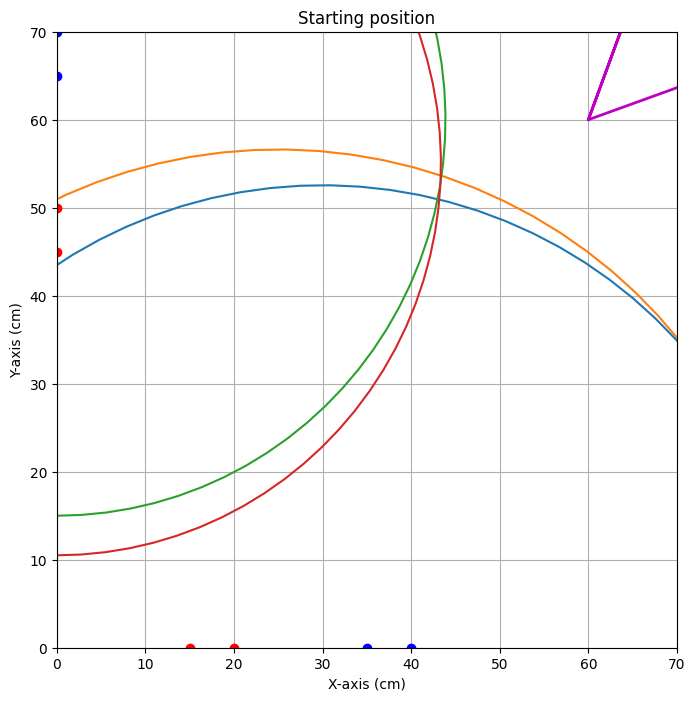


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=34.813


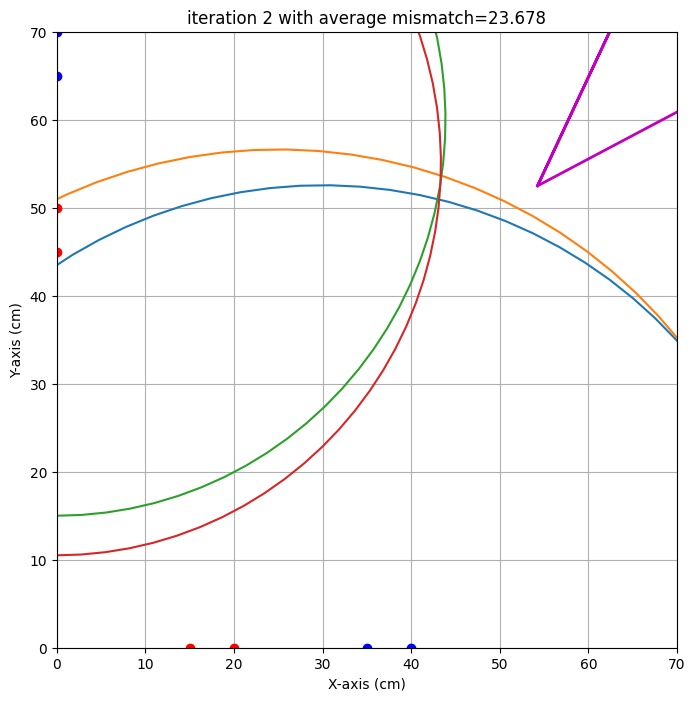

end iteration 2 with average mismatch=23.678


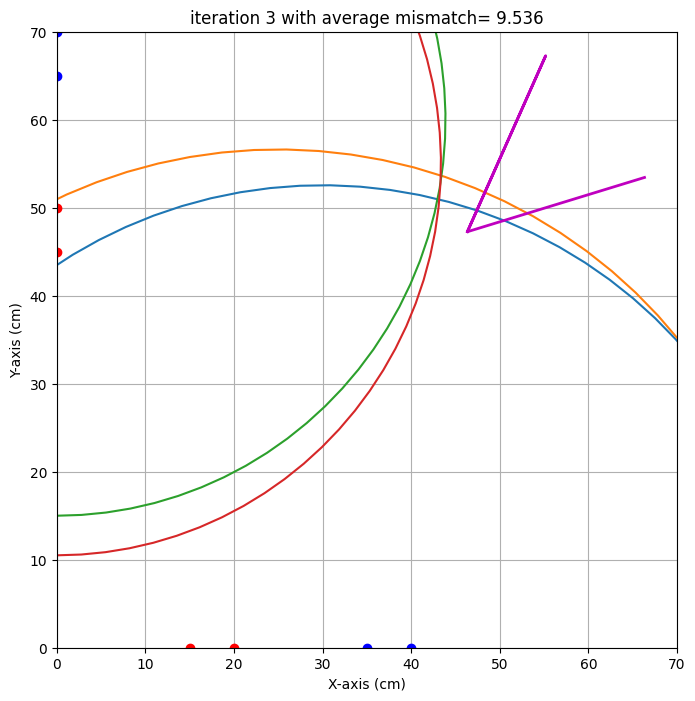

end iteration 3 with average mismatch= 9.536


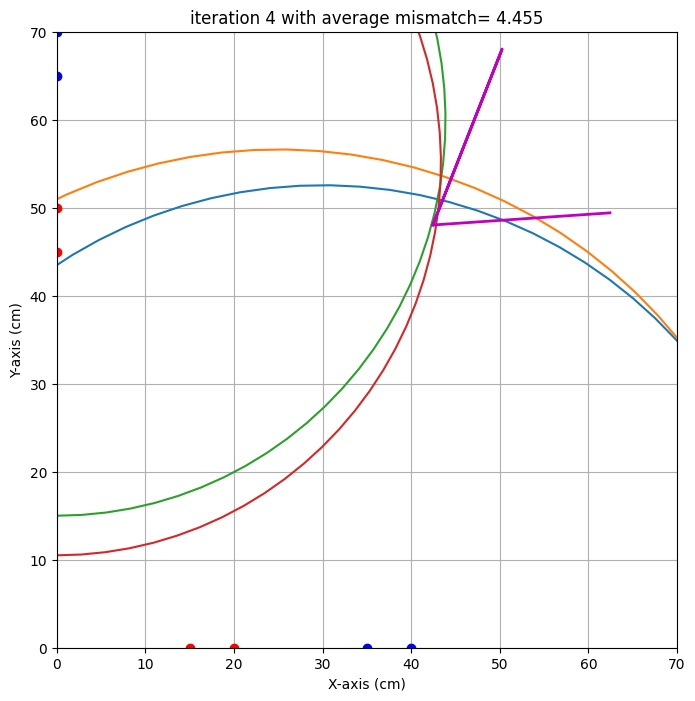

end iteration 4 with average mismatch= 4.455


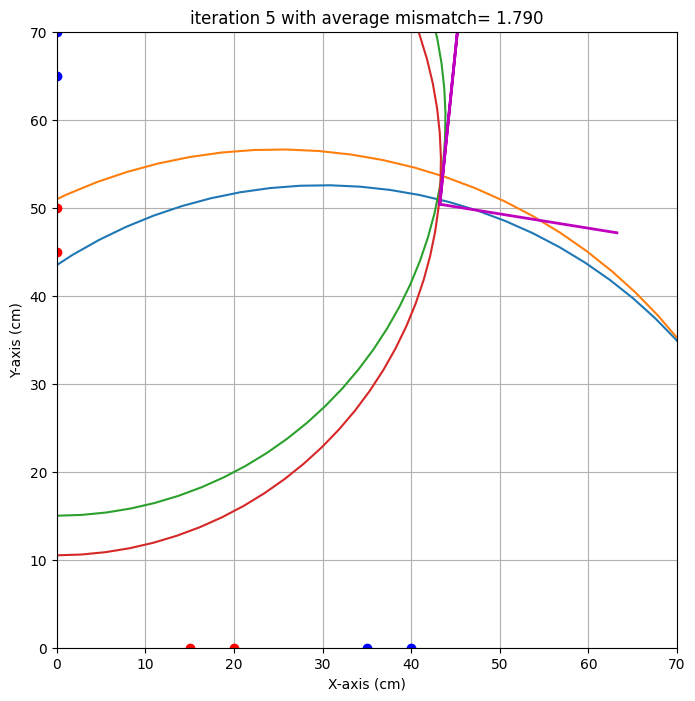

end iteration 5 with average mismatch= 1.790
end iteration 6 with average mismatch= 1.696
end iteration 7 with average mismatch= 1.696
end iteration 8 with average mismatch= 1.618


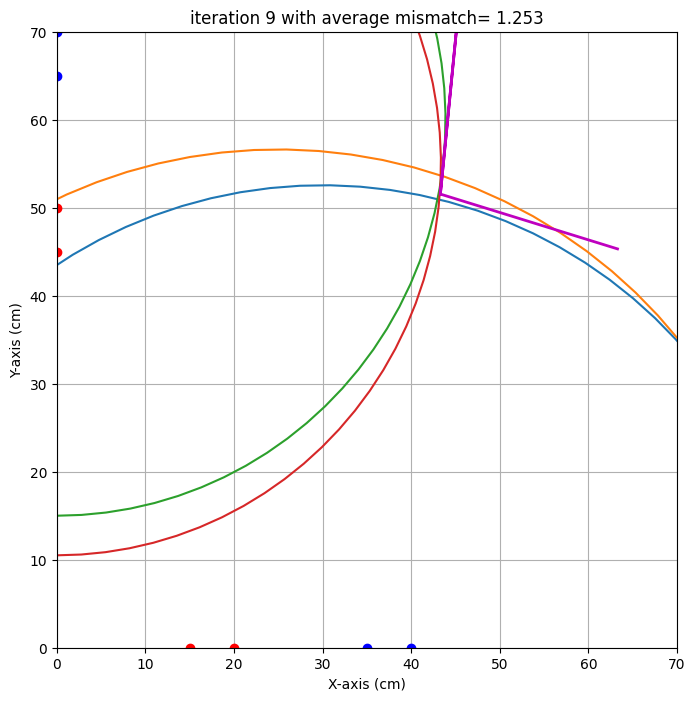

end iteration 9 with average mismatch= 1.253
end iteration 10 with average mismatch= 1.161
end iteration 11 with average mismatch= 1.131
end iteration 12 with average mismatch= 1.125
end iteration 13 with average mismatch= 1.124
end iteration 14 with average mismatch= 1.124
end iteration 15 with average mismatch= 1.124
end iteration 16 with average mismatch= 1.124
end iteration 17 with average mismatch= 1.124
end iteration 18 with average mismatch= 1.124
end iteration 19 with average mismatch= 1.124
end iteration 20 with average mismatch= 1.124
end iteration 21 with average mismatch= 1.124
end iteration 22 with average mismatch= 1.124
end iteration 23 with average mismatch= 1.103
end iteration 24 with average mismatch= 1.101
end iteration 25 with average mismatch= 1.101
end iteration 26 with average mismatch= 1.074
end iteration 27 with average mismatch= 1.074
end iteration 28 with average mismatch= 1.074
end iteration 29 with average mismatch= 1.074
Last iteration, also determine unce

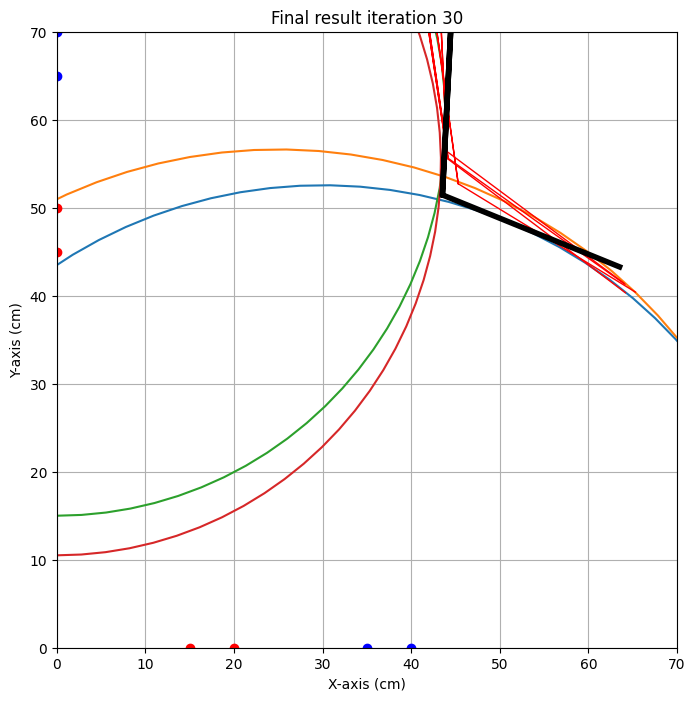

{'alpha': np.float64(-22.23559485600921), 'alpha_eps': np.float64(14.953121563784567), 'beta': np.float64(2.8670462579979237), 'beta_eps': np.float64(11.405811994879388), 'x0': np.float64(43.5246393073562), 'x0_eps': np.float64(1.7885316452488027), 'y0': np.float64(51.45413872647177), 'y0_eps': np.float64(4.933388672416967)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  70   0  83.50
1  45   0  65   0  81.90
2   0  50   0  70  72.50
3   0  45   0  65  70.75
4  35   0  55   0  77.70
5  40   0  60   0  80.20
6  30   0  50   0  76.26
7   0  35   0  55  66.72
8   0  40   0  60  68.52
9   0  30   0  50  67.77


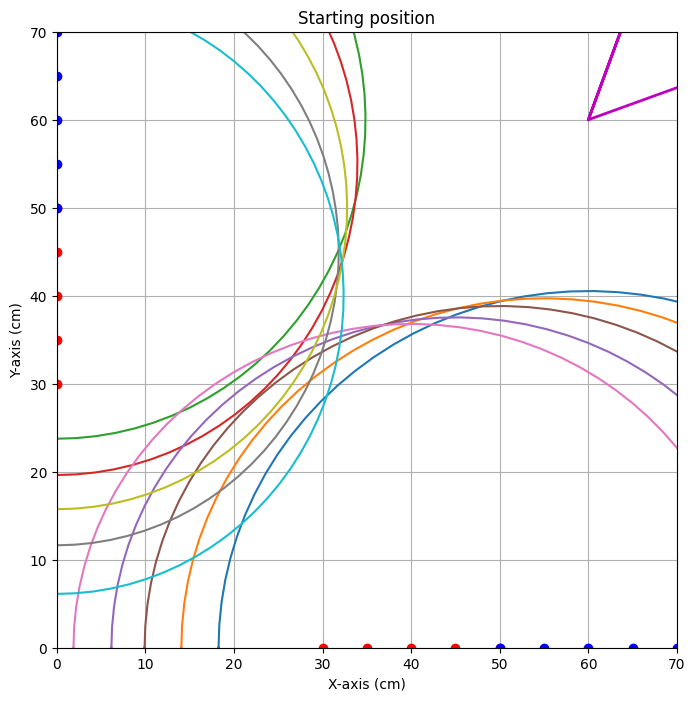


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.460


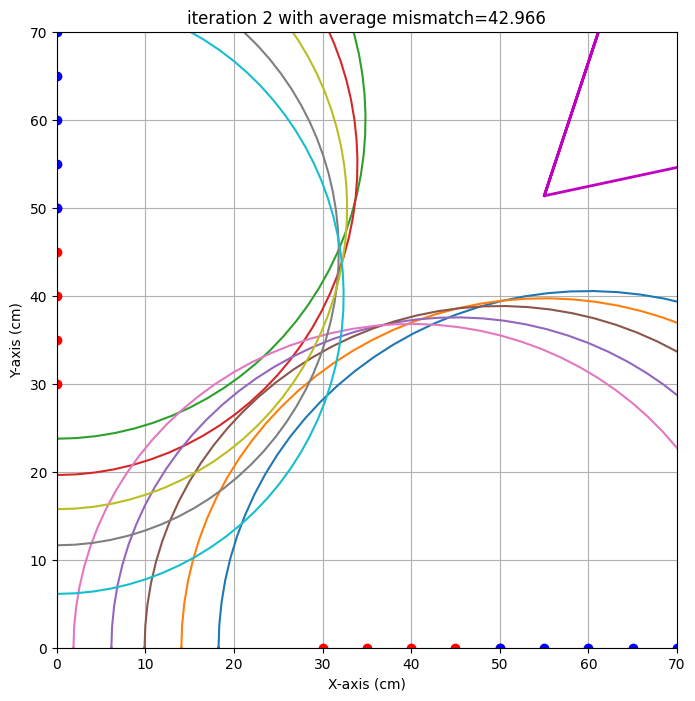

end iteration 2 with average mismatch=42.966


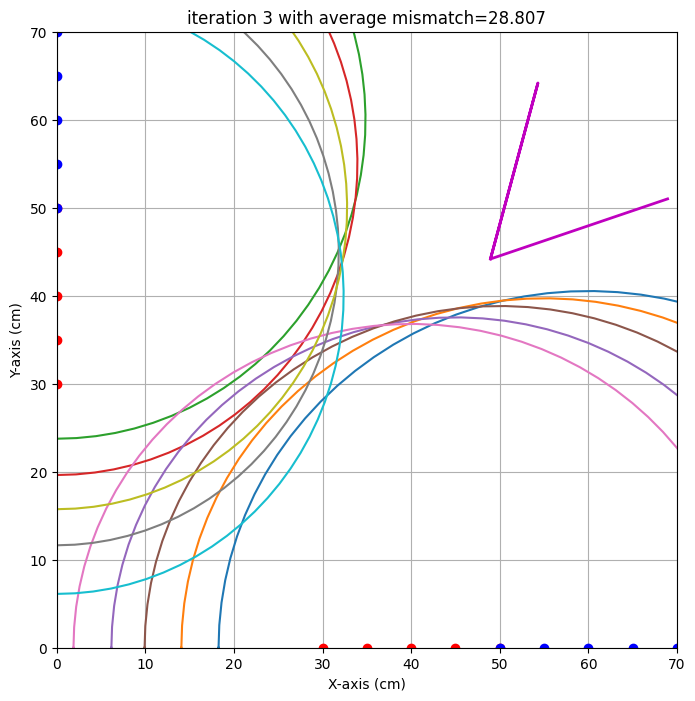

end iteration 3 with average mismatch=28.807


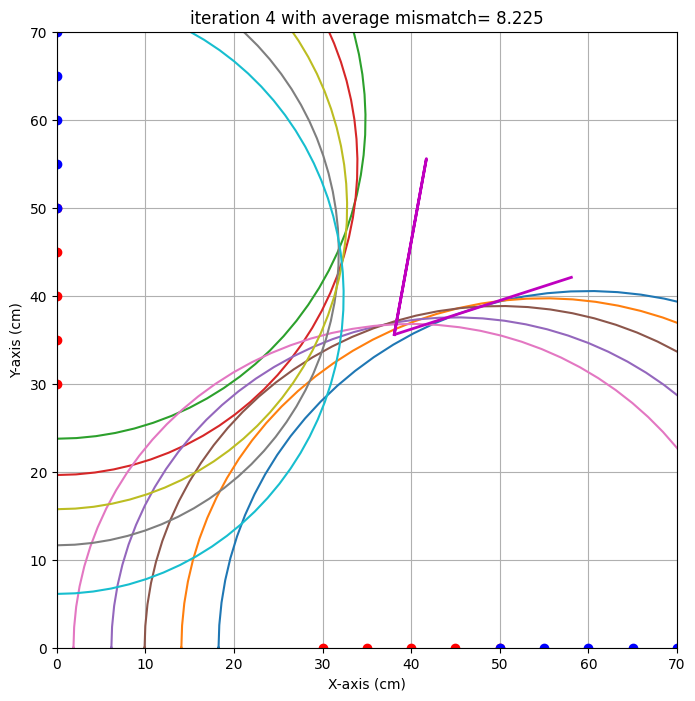

end iteration 4 with average mismatch= 8.225


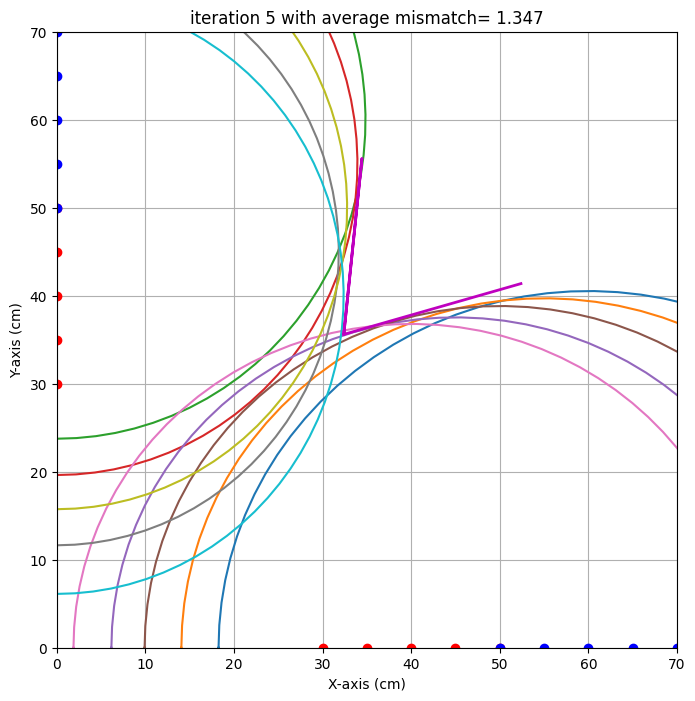

end iteration 5 with average mismatch= 1.347


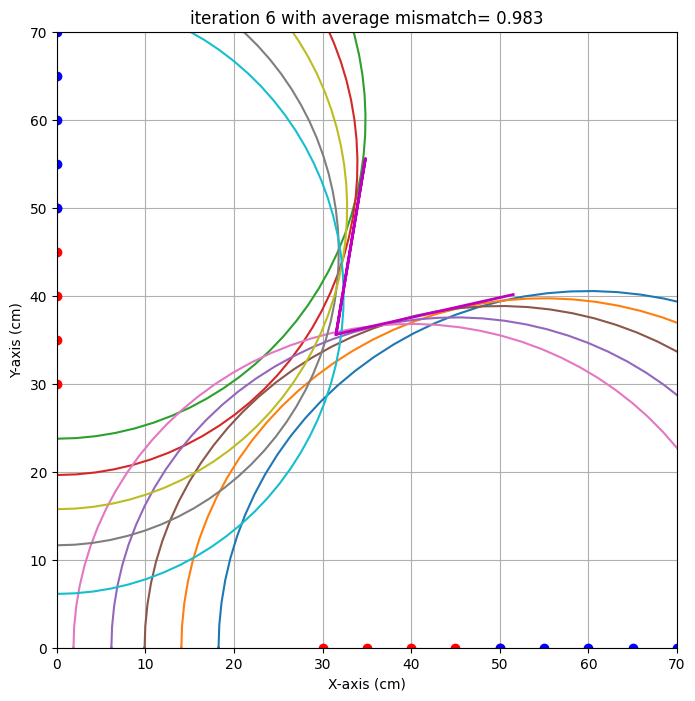

end iteration 6 with average mismatch= 0.983


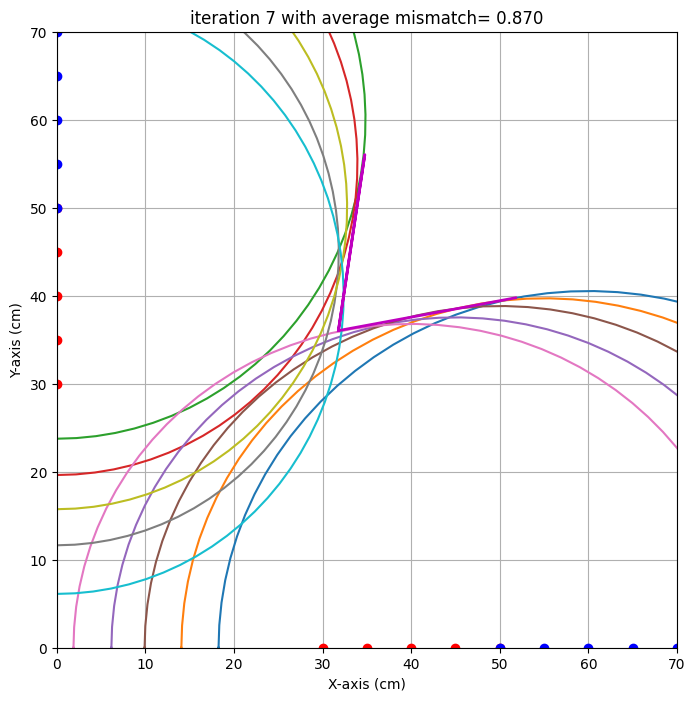

end iteration 7 with average mismatch= 0.870
end iteration 8 with average mismatch= 0.818


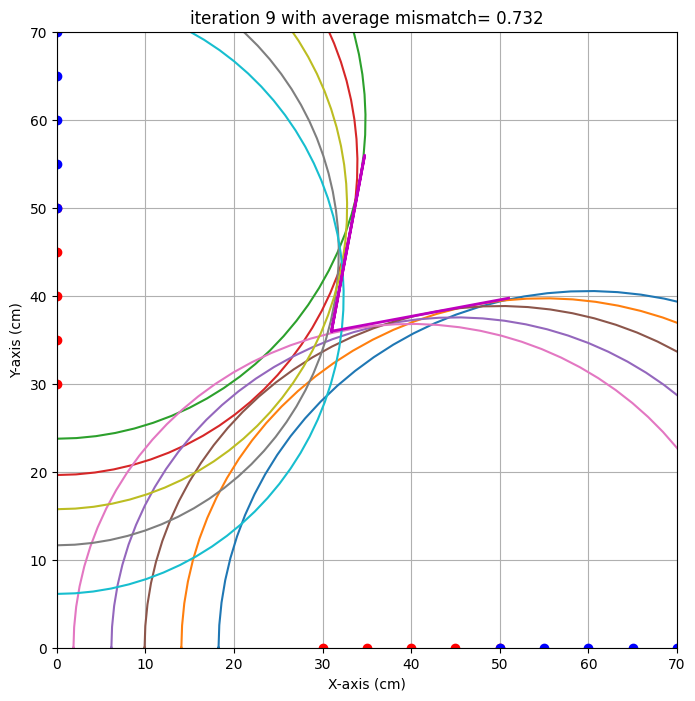

end iteration 9 with average mismatch= 0.732
end iteration 10 with average mismatch= 0.730
end iteration 11 with average mismatch= 0.730
end iteration 12 with average mismatch= 0.730
end iteration 13 with average mismatch= 0.730
end iteration 14 with average mismatch= 0.730
end iteration 15 with average mismatch= 0.730
end iteration 16 with average mismatch= 0.730
end iteration 17 with average mismatch= 0.730
end iteration 18 with average mismatch= 0.730
end iteration 19 with average mismatch= 0.730
end iteration 20 with average mismatch= 0.730
end iteration 21 with average mismatch= 0.730
end iteration 22 with average mismatch= 0.730
end iteration 23 with average mismatch= 0.730
end iteration 24 with average mismatch= 0.730
end iteration 25 with average mismatch= 0.730
end iteration 26 with average mismatch= 0.730
end iteration 27 with average mismatch= 0.730
end iteration 28 with average mismatch= 0.730
end iteration 29 with average mismatch= 0.730
Last iteration, also determine unce

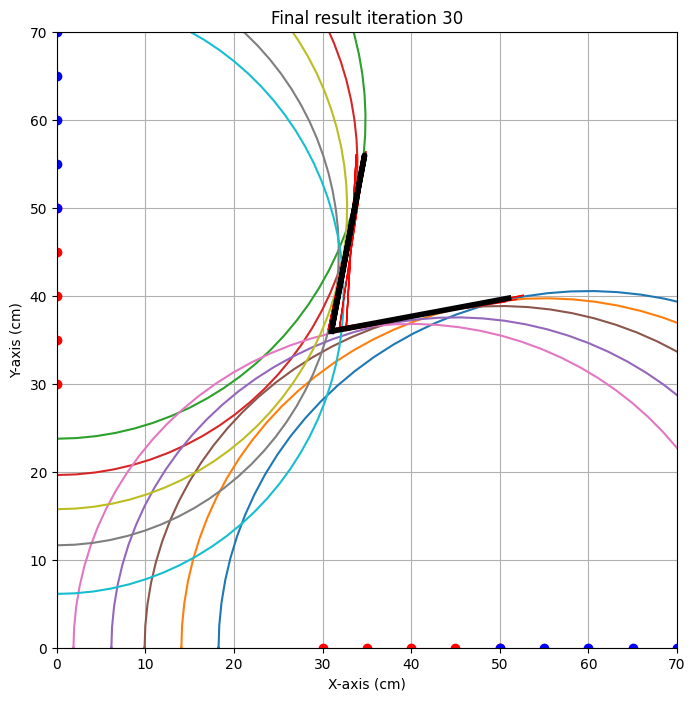

{'alpha': np.float64(10.637287928804517), 'alpha_eps': np.float64(1.7681834358182673), 'beta': np.float64(10.601468646744848), 'beta_eps': np.float64(7.283403156561049), 'x0': np.float64(30.993991401257347), 'x0_eps': np.float64(1.6563954047283502), 'y0': np.float64(35.96515948551449), 'y0_eps': np.float64(0.4349418643555083)}
locatie 1 
x0 target is : 33.5. Gevonden waarde: 43.5 cm met een standaardafwijking van 1.8 cm 
y0 target is : 28.0. Gevonden waarde: 51.5 cm met een standaardafwijking van 4.9 cm 
alpha target is : 65.0. Gevonden waarde: -22.2 graden met een standaardafwijking van 15.0 graad 
beta target is : -51.0. Gevonden waarde: 2.9 graden met een standaardafwijking van 11.4 graad 

locatie 2 
x0 target is : 31.0. Gevonden waarde: 31.0 cm met een standaardafwijking van 1.7 cm 
y0 target is : 35.0. Gevonden waarde: 36.0 cm met een standaardafwijking van 0.4 cm 
alpha target is : 12.0. Gevonden waarde: 10.6 graden met een standaardafwijking van 1.8 graad 
beta target is : 10.0

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':33.5,#zelf aanvullen,
                    'y0':28,#zelf aanvullen,
                    'alpha' :65, #zelf aanvullen,
                    'beta' : -51#zelf aanvullen}, 
},
           'locatie 2':{'x0':31, #zelf aanvullen,
                    'y0':35, #zelf aanvullen,
                    'alpha' :12, #zelf aanvullen,
                    'beta' :10 #zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    #[50,0,70,0,x],
    #[35,0,55,0,x]
    [20,0,40,0,107],
    #[25,0,45,0,x],
    [15,0,35,0,115],
    #[0,20,0,40,x],
    [0,50,0,70,90],
    [0,45,0,65,89]
    ])
    ,
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,x],
    [50,0,70,0,83.5],
    [45,0,65,0,81.9],
    #[0,20,0,40,x],
    [0,50,0,70,72.5],
    [0,45,0,65,70.75],
    [35,0,55,0,77.7],
    [40,0,60,0,80.2],
    [30,0,50,0, 76.26],
    [0,35,0,55,66.72],
    [0,40,0,60,68.52],
    [0,30,0,50,67.77]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  50   0  70   0  125.87
1  45   0  65   0  122.09
2  35   0  55   0  115.50
3  40   0  60   0  117.01
4  30   0  50   0  114.38
5   0  50   0  70   48.79
6   0  45   0  65   51.80
7   0  35   0  55   57.24
8   0  40   0  60   54.01
9   0  30   0  50   61.20


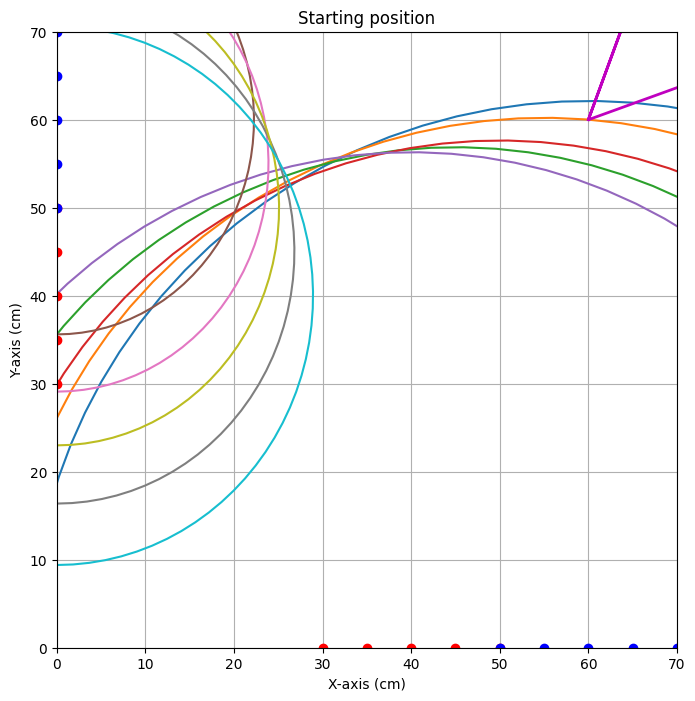


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.979


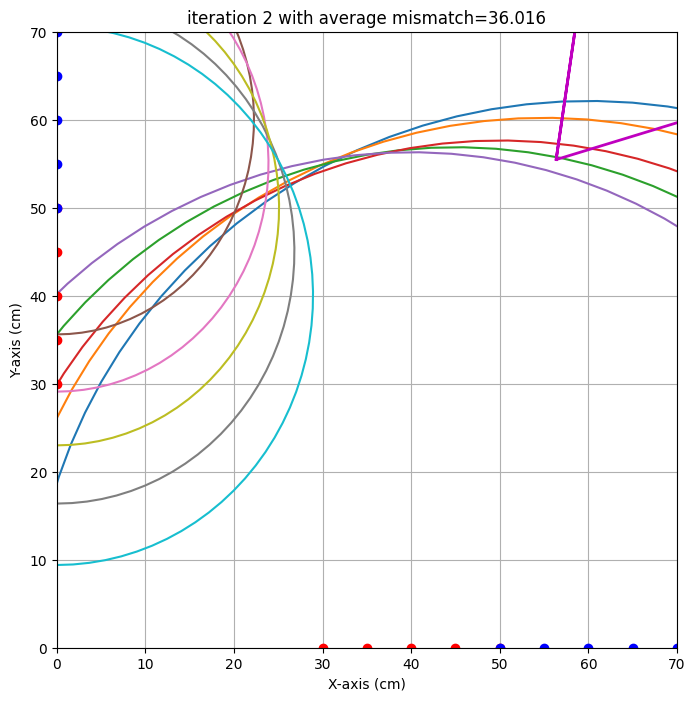

end iteration 2 with average mismatch=36.016


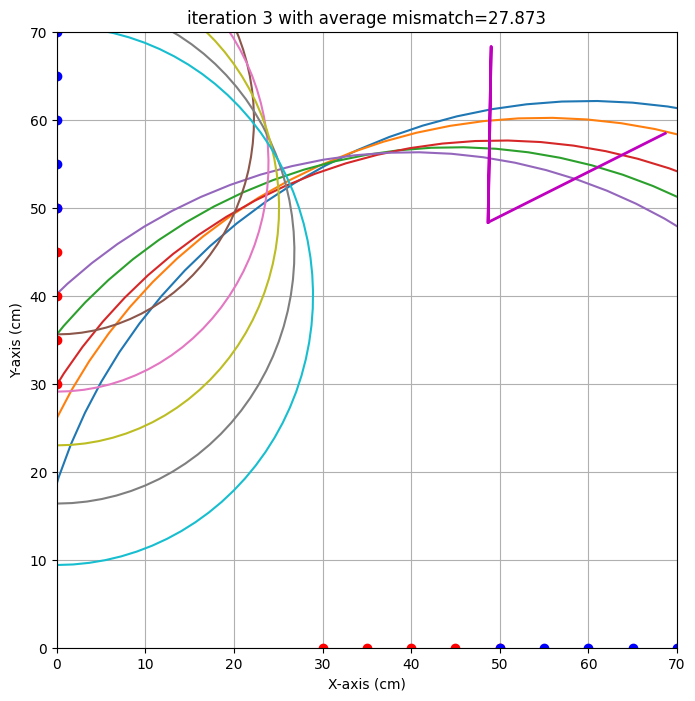

end iteration 3 with average mismatch=27.873


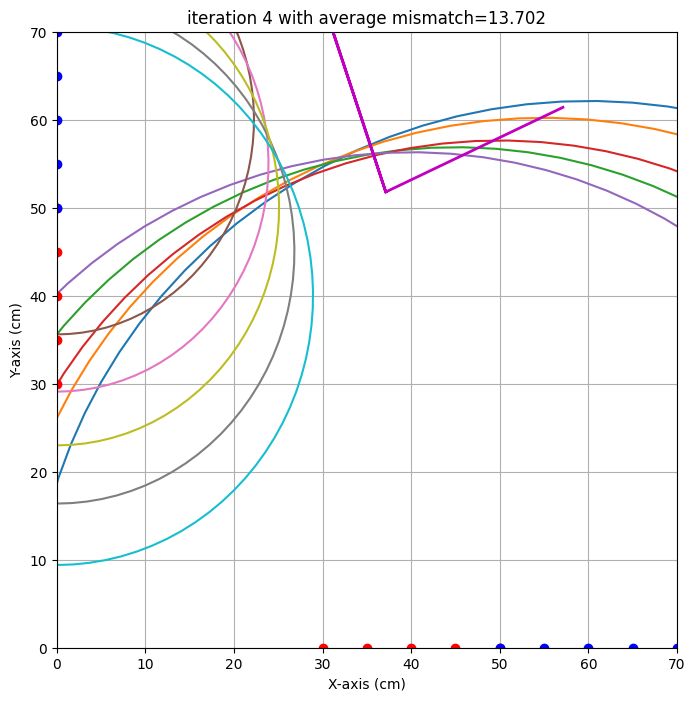

end iteration 4 with average mismatch=13.702


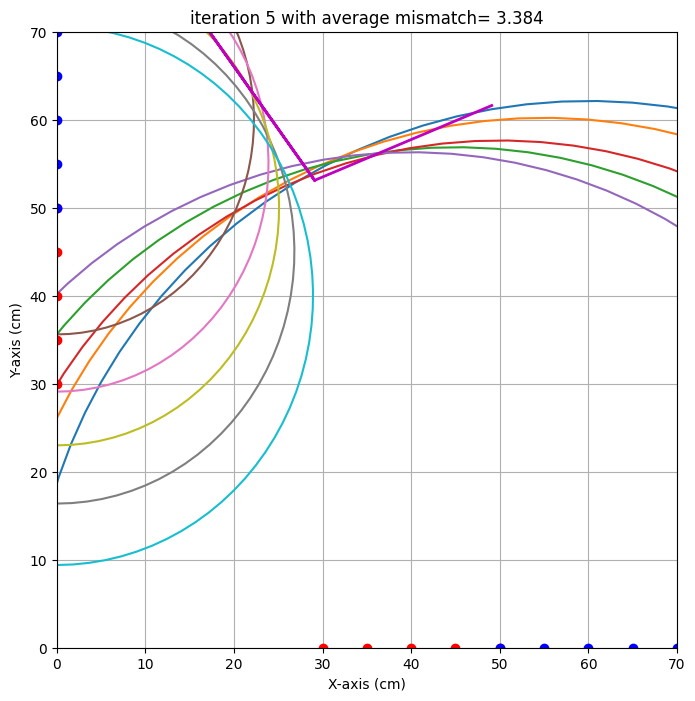

end iteration 5 with average mismatch= 3.384


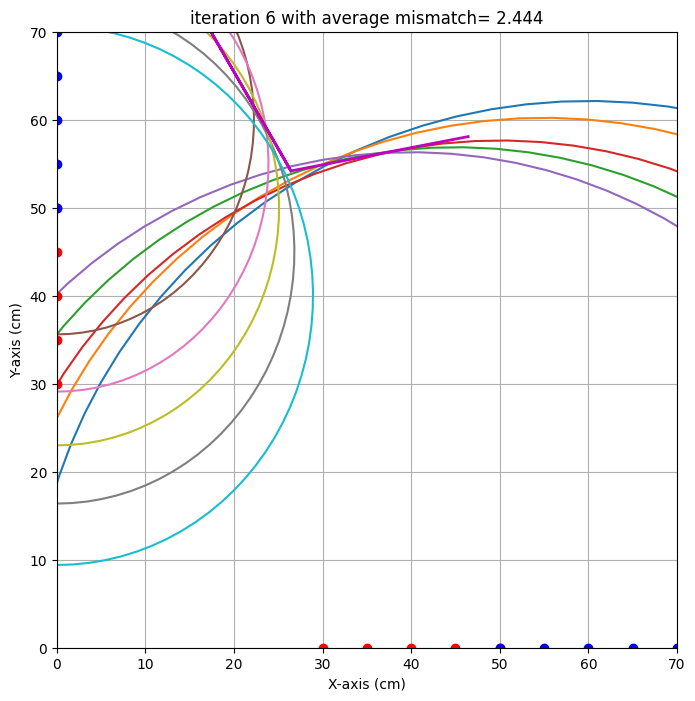

end iteration 6 with average mismatch= 2.444


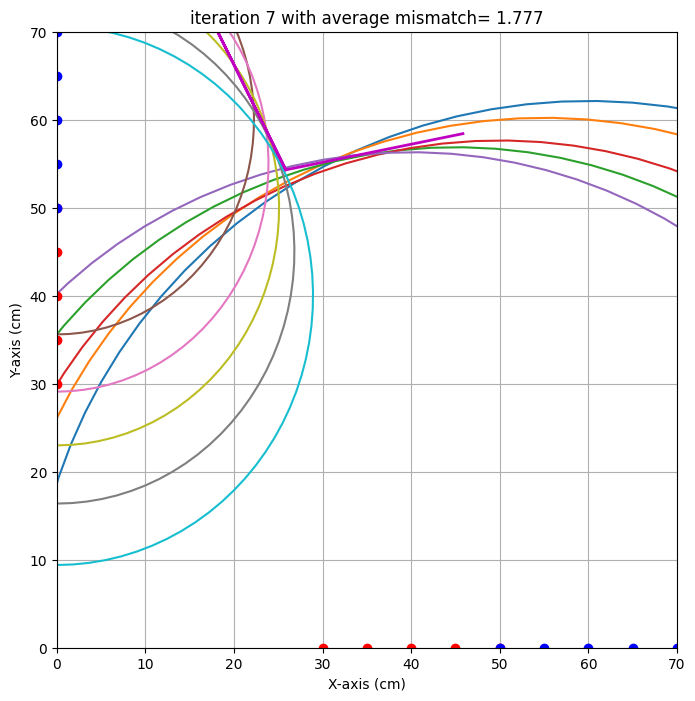

end iteration 7 with average mismatch= 1.777


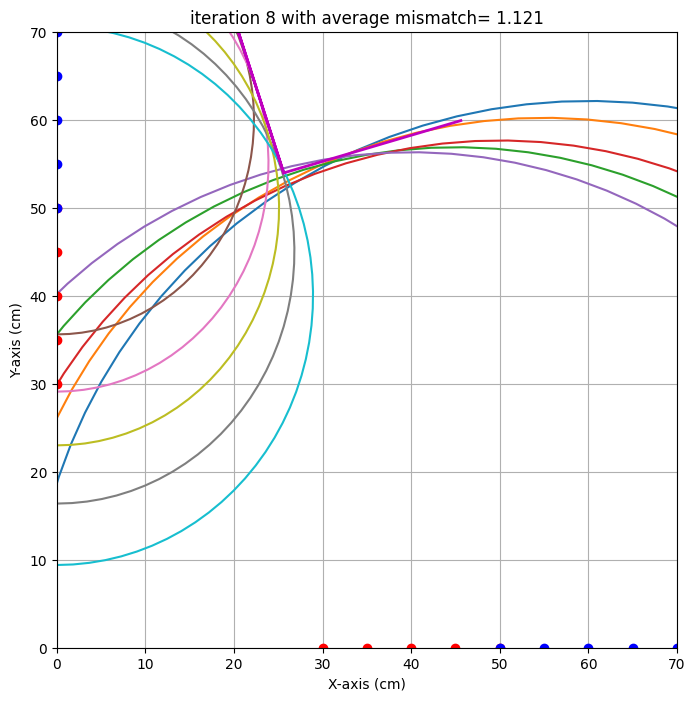

end iteration 8 with average mismatch= 1.121
end iteration 9 with average mismatch= 1.111
end iteration 10 with average mismatch= 1.098
end iteration 11 with average mismatch= 1.092
end iteration 12 with average mismatch= 1.091
end iteration 13 with average mismatch= 0.991
end iteration 14 with average mismatch= 0.984
end iteration 15 with average mismatch= 0.979
end iteration 16 with average mismatch= 0.978
end iteration 17 with average mismatch= 0.977
end iteration 18 with average mismatch= 0.977
end iteration 19 with average mismatch= 0.977
end iteration 20 with average mismatch= 0.977
end iteration 21 with average mismatch= 0.977
end iteration 22 with average mismatch= 0.977
end iteration 23 with average mismatch= 0.977
end iteration 24 with average mismatch= 0.977
end iteration 25 with average mismatch= 0.977
end iteration 26 with average mismatch= 0.977
end iteration 27 with average mismatch= 0.977
end iteration 28 with average mismatch= 0.977
end iteration 29 with average mismat

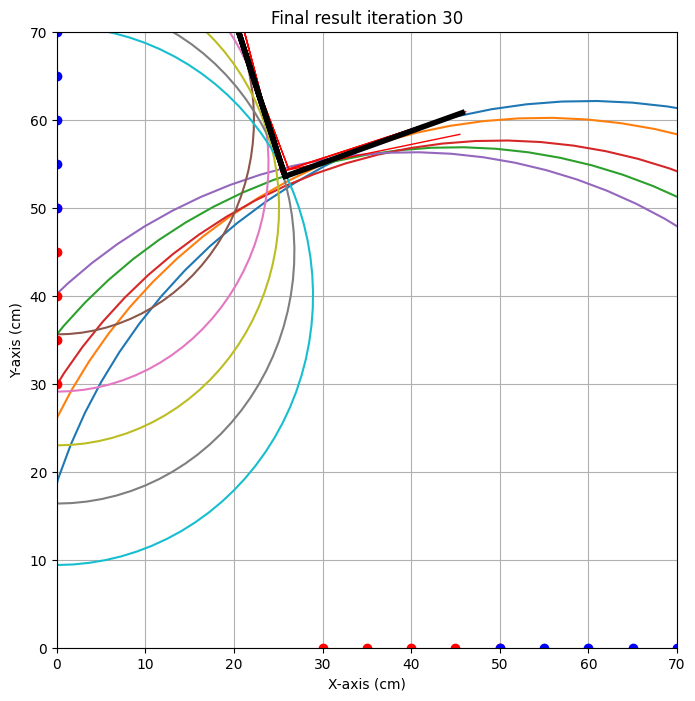

{'alpha': np.float64(19.8560946914917), 'alpha_eps': np.float64(8.069570778347037), 'beta': np.float64(-17.726707086299765), 'beta_eps': np.float64(3.074369404756119), 'x0': np.float64(25.76308848100447), 'x0_eps': np.float64(0.43404931953164194), 'y0': np.float64(53.56728815852326), 'y0_eps': np.float64(0.827373716167159)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 25.8 cm met een standaardafwijking van 0.4 cm 
y0 target is : 49.0. Gevonden waarde: 53.6 cm met een standaardafwijking van 0.8 cm 
alpha target is : 17.0. Gevonden waarde: 19.9 graden met een standaardafwijking van 8.1 graad 
beta target is : -21.0. Gevonden waarde: -17.7 graden met een standaardafwijking van 3.1 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':25,  # zelf aanvullen,
                    'y0':49,  # zelf aanvullen,
                    'alpha' :17,  # zelf aanvullen,
                    'beta' :-21  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                #[20,0,40,0,x],
                [50,0,70,0,125.87],
                [45,0,65,0,122.09],
                [35,0,55,0,115.5],
                [40,0,60,0,117.01],
                [30,0,50,0,114.38],
                #[0,20,0,40,x],
                [0,50,0,70,48.79], #
                [0,45,0,65,51.8],
                [0,35,0,55,57.24],
                [0,40,0,60,54.01],
                [0,30,0,50,61.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

In het begin had ons groepje een gerond bord. Hiermee hebben wij gekalibreerd. Na een tijdje is het bord vervangen door een plat bord omdat onze buren er last van hadden dat het bord rond was. Omdat de borden veranderd zijn is onze kalibratie niet meer accuraat genoeg. Hierdoor komen onze waardes (vooral de y-waarde) niet goed overeen. Als we de ronde tafel hadden gehouden zou het waarschijnlijk wel goed uitgekomen zijn. We hebben ook geprobeerd verschillende data-punten weg te halen, maar dat hielp niet.

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algorBob.jpeg "Het idee van Bob")

Figuur: ![Alt](algorAdam1.jpeg "Het idee van Adam foto 1")

Figuur: ![Alt](algorAdam2.jpeg "Het idee van Adam foto 2")

Figuur: ![Alt](algorDexter.jpeg "Het idee van Dexter")

Figuur: ![Alt](Algorfinal.jpg "Het eind idee van ons. Hierbij hebben we het idee van Bob aangepast door meer metingen te doen. Bij de stappen in regel 2 en 5 werden er maar 2 metingen gedaan. We gaan nu ook door naar regel 3 en 6 om meer metingen uit te voeren. Hierdoor wordt de meting preciezer")